# 0. Objetivo y alcance

Clasificar `Sleep_Stage` en W, N1, N2, N3 y R a partir de señales fisiológicas. Una fila cruda corresponde a una muestra; una fila del ETL, a un epoch completo de 30 segundos.

**Ejecución de referencia:** 77 archivos auditados, 76 pacientes incluidos y 56.850 epochs. Estos valores se contrastan con los datos cargados; no se generan registros para hacerlos coincidir. Las salidas históricas de otras cohortes se retiraron y deben regenerarse sobre esta ejecución.

Recorrido: entrada, auditoría cruda, ETL, análisis descriptivo, transformación candidata y próximos pasos. No se entrenan modelos.


## 0.1. Configuración

Configurar las rutas antes de ejecutar. Por defecto se exige la cohorte de referencia. `MOSTRAR_DETALLE` habilita tablas completas; `MOSTRAR_DIAGNOSTICOS` habilita inspecciones crudas adicionales. Los dos están desactivados para mantener un recorrido breve.


In [1]:
import os
import json
import re
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ES_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ or Path("/kaggle/input").exists()
CARPETA_ENTRADA = Path("/kaggle/input") if ES_KAGGLE else Path("pacientes")
CARPETA_RESULTADOS = Path("/kaggle/working") if ES_KAGGLE else Path.cwd()
COHORTE_REFERENCIA = {"archivos": 77, "pacientes": 76, "epochs": 56850}
EXIGIR_COHORTE_REFERENCIA = True
MOSTRAR_DETALLE = False
MOSTRAR_DIAGNOSTICOS = False
MOSTRAR_PROGRESO = False
SEGUNDOS_EPOCH = 30
TOLERANCIA_TIEMPO = 1e-6

pd.set_option("display.max_columns", 12)
pd.set_option("display.max_colwidth", 80)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

def mostrar_tabla(datos, columnas=None):
    """Mostrar todas las filas de una tabla intencionalmente resumida."""
    vista = datos if columnas is None else datos.loc[:, columnas]
    with pd.option_context("display.max_rows", None):
        display(vista)

def continuidad_temporal(tiempos, siguiente=False):
    """Indicar vecinos reales separados por un epoch, sin atravesar huecos."""
    diferencia = tiempos.shift(-1).sub(tiempos) if siguiente else tiempos.diff()
    return pd.Series(np.isclose(diferencia, SEGUNDOS_EPOCH,
                               atol=TOLERANCIA_TIEMPO, rtol=0),
                     index=tiempos.index)


## 0.2. Claves y exportación

El paciente se repite porque aporta varios epochs. La clave de una observación supervisada es `(patient_id, epoch)`; el mismo instante tampoco puede repetirse dentro del paciente. Las exportaciones validan esa identidad y reemplazan el archivo, sin agregar copias.


In [2]:
# 0.2. Contratos de identidad de filas para todas las salidas CSV
# El paciente puede repetirse; la clave completa depende de qué representa una fila.
esquemas_csv = {
    "auditoria_pacientes.csv": (["archivo"], "un archivo/paciente"),
    "auditoria_senales.csv": (["archivo", "señal"], "una señal de un archivo"),
    "casos_revision.csv": (["archivo", "señal", "motivo", "fila_inicio"], "un caso de revisión"),
    "revision_cambios_etapas.csv": (["archivo", "fila_original"], "un cambio de etapa"),
    "revision_tramos_etiquetas.csv": (["archivo", "fila_inicio"], "un tramo de etiquetas"),
    "revision_estadisticas_sao2.csv": (["archivo"], "un resumen de SAO2 por archivo"),
    "revision_puntos_sao2.csv": (["archivo", "motivo"], "un punto de SAO2 por motivo"),
    "revision_constantes_completas.csv": (["archivo", "señal"], "una señal constante de un archivo"),
    "revision_estadisticas_eda.csv": (["archivo"], "un resumen de EDA por archivo"),
    "revision_puntos_eda.csv": (["archivo", "motivo"], "un punto de EDA por motivo"),
    "dataset_epochs_v1.csv": (["patient_id", "epoch"], "un epoch de 30 segundos"),
    "auditoria_epochs.csv": (["patient_id"], "un resumen ETL por paciente"),
    "epochs_descartados.csv": (["patient_id", "epoch"], "un epoch descartado"),
    "dataset_modelado_candidato.csv": (["patient_id", "epoch"], "un epoch con predictores candidatos"),
}
registro_csv = {}


def validar_clave_tabla(datos, claves, nombre):
    """Rechazar identidades faltantes o repetidas; conservar epochs legítimos."""
    faltantes = set(claves).difference(datos.columns)
    if faltantes:
        raise ValueError(f"{nombre}: faltan columnas de la clave {sorted(faltantes)}.")
    if datos[claves].isna().any().any():
        raise ValueError(f"{nombre}: hay valores faltantes en la clave {claves}.")
    repetidas = datos.duplicated(claves, keep=False)
    if repetidas.any():
        ejemplos = datos.loc[repetidas, claves].head(6).to_dict("records")
        raise ValueError(
            f"{nombre}: {int(repetidas.sum())} filas con clave repetida {claves}. "
            f"Ejemplos: {ejemplos}. Revisar el origen o la unión que multiplicó filas."
        )


def validar_tabla_csv(datos, ruta):
    """Verificar el grano declarado sin borrar filas ni cambiar valores."""
    nombre = Path(ruta).name
    if nombre not in esquemas_csv:
        raise ValueError(f"{nombre}: declarar su clave en esquemas_csv antes de exportar.")
    if datos.columns.duplicated().any():
        raise ValueError(f"{nombre}: hay nombres de columnas duplicados.")
    claves, unidad = esquemas_csv[nombre]
    validar_clave_tabla(datos, claves, nombre)
    if nombre in {"dataset_epochs_v1.csv", "dataset_modelado_candidato.csv"}:
        # Detecta el mismo instante incluso si recibió otro número de epoch.
        validar_clave_tabla(datos, ["patient_id", "tiempo_relativo_segundos"], nombre)
    return {
        "csv": nombre, "una_fila_representa": unidad, "clave": " + ".join(claves),
        "filas": len(datos), "columnas": len(datos.columns),
        "claves_repetidas": int(datos.duplicated(claves).sum()),
        "filas_identicas": 0,  # La clave única validada ya impide filas idénticas, incluso con listas.
    }


def registrar_csv_validado(datos, ruta, origen="caché validada"):
    resumen = validar_tabla_csv(datos, ruta)
    resumen["origen"] = origen
    registro_csv[str(Path(ruta).resolve())] = resumen
    return resumen


def exportar_csv_validado(datos, ruta):
    """Validar y reemplazar la salida; reejecutar no agrega copias al archivo."""
    resumen = validar_tabla_csv(datos, ruta)
    datos.to_csv(ruta, index=False, mode="w")
    resumen["origen"] = "exportado (reemplazo)"
    registro_csv[str(Path(ruta).resolve())] = resumen
    return resumen


# 1. Entrada y reglas temporales

Se detectan los CSV, se valida su identidad y se conserva un paciente crudo para ilustrar el formato. El procesamiento global y los conteos de la cohorte no dependen de esa muestra.


In [3]:
# 1.1. Detección automática de entorno y listado de archivos
def get_dataset_files(data_dir=None):
    """Buscar solo en la carpeta de entrada configurada."""
    raiz = CARPETA_ENTRADA if data_dir is None else Path(data_dir)
    if not raiz.exists():
        raise FileNotFoundError(f"Carpeta de entrada inexistente: {raiz}")
    archivos = sorted(raiz.rglob("S*_PSG_df.csv"), key=lambda p: p.name)
    if not archivos:
        raise ValueError("No se encontraron CSV de pacientes.")
    nombres = [p.name for p in archivos]
    if len(nombres) != len(set(nombres)):
        raise ValueError("Hay nombres de archivo duplicados en la entrada.")
    ids = [extract_patient_id(p) for p in archivos]
    if len(ids) != len(set(ids)):
        raise ValueError("Un paciente tiene más de un archivo en la entrada.")
    if EXIGIR_COHORTE_REFERENCIA and len(archivos) != COHORTE_REFERENCIA["archivos"]:
        raise ValueError(
            f"Se esperaban {COHORTE_REFERENCIA['archivos']} archivos; hay {len(archivos)}. "
            "Configurar la entrada con la ejecución de referencia antes de continuar."
        )
    print(f"Archivos detectados: {len(archivos)}")
    return archivos

def extract_patient_id(file_path: Path | str) -> int:
    """
    Extrae el identificador numérico de paciente desde el nombre de archivo (ej. 'S005_PSG_df.csv' -> 5).
    """
    filename = Path(file_path).name
    match = re.search(r'S(\d+)_PSG_df\.csv', filename, re.IGNORECASE)
    if match:
        return int(match.group(1))
    digits = re.search(r'\d+', filename)
    return int(digits.group(0)) if digits else -1

data_files = get_dataset_files()
if data_files:
    print("Ejemplo de archivos detectados:", [f.name for f in data_files[:5]])

# Función temporal compartida por el EDA y el ETL.
def definir_epochs(df):
    """
    Identifica una alineación candidata a partir de cambios de etapas válidas.
    Marca los bordes incompletos para excluirlos del agregado y auditarlos.
    No modifica el DataFrame recibido.
    """
    columnas_requeridas = {"TIMESTAMP", "Sleep_Stage"}
    faltantes = columnas_requeridas.difference(df.columns)

    if faltantes:
        raise ValueError(f"Faltan columnas: {sorted(faltantes)}")

    if len(df) < 3000:
        raise ValueError("El registro contiene menos de 30 segundos.")

    tiempos = pd.to_numeric(df["TIMESTAMP"], errors="coerce")

    if not np.isfinite(tiempos).all():
        raise ValueError("Hay timestamps faltantes o inválidos.")

    diferencias = tiempos.diff().iloc[1:]
    if not np.isclose(
        diferencias, 0.01, atol=1e-6, rtol=0
    ).all():
        raise ValueError("El registro no es continuo a 100 Hz.")

    etapas = df["Sleep_Stage"]
    anterior = etapas.shift()
    validas = {"W", "N1", "N2", "N3", "R"}

    cambios = (
        etapas.isin(validas)
        & anterior.isin(validas)
        & etapas.ne(anterior)
    )

    posiciones = np.flatnonzero(cambios.to_numpy())
    restos = np.unique(posiciones % 3000)

    if len(restos) == 0:
        raise ValueError(
            "Sin cambios entre etapas válidas: alineación no determinada."
        )

    if len(restos) > 1:
        raise ValueError(
            f"Alineación inconsistente: desplazamientos {restos.tolist()}."
        )

    desplazamiento = int(restos[0])
    cantidad_completos = (len(df) - desplazamiento) // 3000

    epoch = (np.arange(len(df)) - desplazamiento) // 3000
    completo = (epoch >= 0) & (epoch < cantidad_completos)

    resumen = {
        "filas_originales": len(df),
        "desplazamiento": desplazamiento,
        "epochs_completos": cantidad_completos,
        "filas_fragmento_inicial": desplazamiento,
        "filas_fragmento_final":
            (len(df) - desplazamiento) % 3000
    }

    return epoch, completo, resumen


Archivos detectados: 77
Ejemplo de archivos detectados: ['S002_PSG_df.csv', 'S003_PSG_df.csv', 'S004_PSG_df.csv', 'S005_PSG_df.csv', 'S006_PSG_df.csv']


In [4]:
# Muestra individual: solo columnas necesarias para ilustrar las señales.
sample_file = next((p for p in data_files if p.name == "S002_PSG_df.csv"), data_files[0])
columnas_muestra = ["TIMESTAMP", "Sleep_Stage", "EDA", "BVP", "HR", "TEMP",
                    "ACC_X", "ACC_Y", "ACC_Z"]
df_sample_eda = pd.read_csv(sample_file, usecols=columnas_muestra)
print(f"Muestra cruda: {sample_file.name}; no representa toda la cohorte.")


Muestra cruda: S002_PSG_df.csv; no representa toda la cohorte.


# 2. EDA de los registros crudos

La auditoría revisa todos los archivos. Busca problemas de estructura, valores, continuidad y anotaciones antes de construir epochs. Una señal extrema o constante requiere contexto: no demuestra por sí sola un defecto.


### Variables originales

| Familia | Señales | Interpretación |
| --- | --- | --- |
| Pulso y frecuencia | BVP, HR, IBI | Amplitud óptica, frecuencia cardíaca e intervalos entre latidos; no son intercambiables. |
| Piel | EDA, TEMP | Conductancia y temperatura registradas por el wearable. |
| Movimiento | ACC_X, ACC_Y, ACC_Z | Componentes de aceleración; confirmar unidades de origen. |
| PSG | EEG, E1/E2, CHIN, ECG, LAT/RAT y respiratorias | Señales de distintos sensores; amplitud y dispersión no equivalen a diagnóstico. |
| Saturación | SAO2 | Escala y procesamiento pendientes de confirmación. |
| Tiempo y etiquetas | TIMESTAMP, Sleep_Stage, anotaciones de apnea | Tiempo, objetivo y otras anotaciones. No se incorporan automáticamente a los predictores. |

Las anotaciones de apnea se dejan fuera del candidato inicial por su disponibilidad y origen: pueden ser información privilegiada que no exista al predecir. No basta decir que se excluyen porque no son el objetivo.


## 2.1. Ficha de entrada

Una muestra corresponde a 0,01 segundos si se verifica continuidad a 100 Hz. Las señales son numéricas y la etapa es categórica. La comparación completa de esquemas y valores inválidos se realiza en la auditoría global.


In [5]:
columnas_entrada = pd.read_csv(sample_file, nrows=0).columns.tolist()
mostrar_tabla(pd.DataFrame([{
    "archivos_detectados": len(data_files),
    "columnas_del_archivo_muestra": len(columnas_entrada),
    "archivo_muestra": sample_file.name,
    "muestras_por_epoch": 3000,
    "objetivo": "Sleep_Stage",
}]))
if MOSTRAR_DETALLE:
    mostrar_tabla(pd.DataFrame({"columna_original": columnas_entrada}))


,archivos_detectados,columnas_del_archivo_muestra,archivo_muestra,muestras_por_epoch,objetivo
0,77,32,S002_PSG_df.csv,3000,Sleep_Stage


## 2.2. Auditoría global

Procesar los CSV por bloques y guardar auditorías completas. El resumen distingue errores de lectura, problemas de alineación y valores inválidos. Una alineación candidata consistente no certifica toda la calidad instrumental.


In [6]:
# 2.2. Auditoría general por bloques

TAMANO_BLOQUE = 200_000

# Criterio exploratorio para listar tramos constantes.
# No es un umbral de limpieza ni demuestra un fallo del sensor.
SEGUNDOS_CONSTANTES_REVISION = 30

archivos_auditar = list(data_files)

if not archivos_auditar:
    raise ValueError("No hay archivos para auditar.")

nombres = [p.name for p in archivos_auditar]
if len(nombres) != len(set(nombres)):
    raise ValueError(
        "Hay nombres de archivo duplicados. Revisar data_files."
    )

print("Archivos encontrados:", len(archivos_auditar))

# S002 se utiliza únicamente como referencia de columnas.
referencia = next(
    (p for p in archivos_auditar if p.name == "S002_PSG_df.csv"),
    archivos_auditar[0],
)
columnas_referencia = pd.read_csv(referencia, nrows=0).columns.tolist()

excluidas = {
    "TIMESTAMP", "Sleep_Stage", "patient_id",
    "Obstructive_Apnea", "Central_Apnea",
    "Hypopnea", "Multiple_Events",
}
senales_referencia = [
    c for c in columnas_referencia if c not in excluidas
]
etapas_validas = ["W", "N1", "N2", "N3", "R"]

# Evitar releer todos los CSV de 100 Hz si la auditoría sigue vigente.
FORZAR_RECALCULO_AUDITORIA = False
AUDITORIA_CACHE_VERSION = 1  # Incrementar si cambia la lógica de auditoría.
carpeta_salida = CARPETA_RESULTADOS / "auditoria"
rutas_auditoria = {
    "pacientes": carpeta_salida / "auditoria_pacientes.csv",
    "senales": carpeta_salida / "auditoria_senales.csv",
    "casos": carpeta_salida / "casos_revision.csv",
}
ruta_manifiesto_auditoria = carpeta_salida / "manifest_auditoria_v1.json"
firma_auditoria = {
    "version": AUDITORIA_CACHE_VERSION,
    "tamano_bloque": TAMANO_BLOQUE,
    "segundos_constantes_revision": SEGUNDOS_CONSTANTES_REVISION,
    "columnas_referencia": columnas_referencia,
    "senales_referencia": senales_referencia,
    "etapas_validas": etapas_validas,
    "fuentes": [
        {
            "archivo": ruta.name, "ruta": str(ruta.resolve()),
            "bytes": ruta.stat().st_size,
            "mtime_ns": ruta.stat().st_mtime_ns,
        }
        for ruta in sorted(archivos_auditar, key=lambda p: p.name)
    ],
}
cache_auditoria_valida = False
if (not FORZAR_RECALCULO_AUDITORIA
        and ruta_manifiesto_auditoria.exists()
        and all(ruta.exists() for ruta in rutas_auditoria.values())):
    try:
        with ruta_manifiesto_auditoria.open(encoding="utf-8") as archivo:
            manifiesto_auditoria = json.load(archivo)
        if manifiesto_auditoria.get("firma") != firma_auditoria:
            raise ValueError("Las fuentes o reglas de auditoría cambiaron")
        pacientes_cache = pd.read_csv(rutas_auditoria["pacientes"], low_memory=False)
        senales_cache = pd.read_csv(rutas_auditoria["senales"], low_memory=False)
        casos_cache = pd.read_csv(rutas_auditoria["casos"], low_memory=False)
        if manifiesto_auditoria.get("filas") != {
            "pacientes": len(pacientes_cache),
            "senales": len(senales_cache),
            "casos": len(casos_cache),
        }:
            raise ValueError("Las tablas no coinciden con el manifiesto")
        if (len(pacientes_cache) != len(archivos_auditar)
            or pacientes_cache["archivo"].duplicated().any()
            or set(pacientes_cache["archivo"]) != set(nombres)
            or not pacientes_cache["estado_lectura"].eq("Completa").all()):
            raise ValueError("La auditoría de pacientes está incompleta")
        if not {"archivo", "señal", "nulos", "no_numericos", "infinitos"}.issubset(senales_cache.columns):
            raise ValueError("Faltan columnas en la auditoría de señales")
        if not {"archivo", "señal", "motivo"}.issubset(casos_cache.columns):
            raise ValueError("Faltan columnas en los casos de revisión")
        if (not set(senales_cache["archivo"]).issubset(nombres)
            or not set(casos_cache["archivo"]).issubset(nombres)):
            raise ValueError("Las tablas contienen archivos ajenos a las fuentes")
        for nombre_tabla, tabla in [
            ("pacientes", pacientes_cache), ("senales", senales_cache), ("casos", casos_cache)
        ]:
            registrar_csv_validado(tabla, rutas_auditoria[nombre_tabla])
        cache_auditoria_valida = True
        print("Auditoría cargada desde CSV existente:", carpeta_salida)
    except (OSError, ValueError, KeyError, pd.errors.ParserError) as error:
        print(f"Caché de auditoría no utilizable ({error}); se recalculará.")

if not cache_auditoria_valida:
    carpeta_salida.mkdir(parents=True, exist_ok=True)
    ruta_manifiesto_auditoria.unlink(missing_ok=True)
    print("Se auditarán los CSV originales por bloques.")


def nuevo_tramo():
    return {
        "cola": 0,
        "mayor": 0,
        "inicio": None,
    }


def actualizar_tramo(mascara, estado, fila_inicio):
    """Mayor tramo True, incluyendo continuidad entre bloques."""
    mascara = np.asarray(mascara, dtype=bool)

    if len(mascara) == 0:
        return

    cambios = np.diff(
        np.r_[False, mascara, False].astype(np.int8)
    )
    inicios = np.flatnonzero(cambios == 1)
    finales = np.flatnonzero(cambios == -1)

    if len(inicios) == 0:
        estado["cola"] = 0
        return

    largos = finales - inicios
    posiciones = fila_inicio + inicios

    if inicios[0] == 0:
        largos[0] += estado["cola"]
        posiciones[0] -= estado["cola"]

    mayor = int(np.argmax(largos))

    if largos[mayor] > estado["mayor"]:
        estado["mayor"] = int(largos[mayor])
        estado["inicio"] = int(posiciones[mayor])

    estado["cola"] = (
        int(largos[-1]) if mascara[-1] else 0
    )


resultados_pacientes = []
resultados_senales = []
casos_revision = []

for numero, ruta in enumerate(archivos_auditar if not cache_auditoria_valida else [], start=1):
    print(
        f"[{numero}/{len(archivos_auditar)}] {ruta.name}",
        flush=True,
    )

    try:
        columnas = pd.read_csv(ruta, nrows=0).columns.tolist()
        columnas_faltantes = sorted(
            set(columnas_referencia) - set(columnas)
        )
        columnas_adicionales = sorted(
            set(columnas) - set(columnas_referencia)
        )

        requeridas = {"TIMESTAMP", "Sleep_Stage"}
        if not requeridas.issubset(columnas):
            raise ValueError("Falta TIMESTAMP o Sleep_Stage.")

        senales = [
            c for c in senales_referencia if c in columnas
        ]

        controles = {
            c: {
                "nulos": 0,
                "no_numericos": 0,
                "infinitos": 0,
                "minimo": np.inf,
                "maximo": -np.inf,
                "tipos": set(),
                "anterior": np.nan,
                "constante": nuevo_tramo(),
            }
            for c in senales
        }

        filas = 0
        timestamp_anterior = None
        etapa_anterior = None
        timestamp_inicio = None
        timestamp_final = None

        timestamps_invalidos = 0
        intervalos_irregulares = 0
        intervalos_no_crecientes = 0

        etiquetas_nulas = 0
        etiquetas_invalidas = 0
        valores_invalidos = set()
        conteos_etapas = {e: 0 for e in etapas_validas}

        restos = set()
        cambios_etapa = 0
        ceros_sao2 = 0
        sao2_fuera_0_1 = 0
        tramo_ceros = nuevo_tramo()

        columnas_leer = ["TIMESTAMP", "Sleep_Stage"] + senales

        with pd.read_csv(
            ruta,
            usecols=columnas_leer,
            chunksize=TAMANO_BLOQUE,
            low_memory=False,
        ) as lector:

            for bloque in lector:
                fila_inicio = filas
                cantidad = len(bloque)

                # 1. Tiempo: incluir el límite entre bloques.
                t = pd.to_numeric(
                    bloque["TIMESTAMP"], errors="coerce"
                ).to_numpy(dtype=float)

                if timestamp_inicio is None:
                    timestamp_inicio = t[0]
                timestamp_final = t[-1]

                timestamps_invalidos += int(
                    (~np.isfinite(t)).sum()
                )

                tiempos_comparar = (
                    np.r_[timestamp_anterior, t]
                    if timestamp_anterior is not None
                    else t
                )

                diferencias = np.diff(tiempos_comparar)
                pares_finitos = (
                    np.isfinite(tiempos_comparar[:-1])
                    & np.isfinite(tiempos_comparar[1:])
                )

                intervalos_irregulares += int(
                    (
                        pares_finitos
                        & ~np.isclose(
                            diferencias, 0.01,
                            atol=1e-6, rtol=0,
                        )
                    ).sum()
                )
                intervalos_no_crecientes += int(
                    (pares_finitos & (diferencias <= 0)).sum()
                )
                timestamp_anterior = t[-1]

                # 2. Etiquetas y alineación.
                etapas = bloque["Sleep_Stage"].reset_index(drop=True)
                anteriores = etapas.shift()
                if fila_inicio > 0:
                    anteriores.iloc[0] = etapa_anterior

                invalidas = (
                    etapas.notna()
                    & ~etapas.isin(etapas_validas)
                )

                etiquetas_nulas += int(etapas.isna().sum())
                etiquetas_invalidas += int(invalidas.sum())
                valores_invalidos.update(
                    etapas.loc[invalidas].astype(str).unique()
                )

                conteos = etapas.value_counts()
                for etapa in etapas_validas:
                    conteos_etapas[etapa] += int(
                        conteos.get(etapa, 0)
                    )

                cambios = (
                    etapas.isin(etapas_validas)
                    & anteriores.isin(etapas_validas)
                    & etapas.ne(anteriores)
                )

                posiciones = (
                    np.flatnonzero(cambios.to_numpy())
                    + fila_inicio
                )

                cambios_etapa += len(posiciones)
                restos.update((posiciones % 3000).tolist())
                etapa_anterior = etapas.iloc[-1]

                # 3. Calidad y rangos de cada señal.
                for col in senales:
                    control = controles[col]
                    original = bloque[col]
                    control["tipos"].add(str(original.dtype))

                    numerico = pd.to_numeric(
                        original, errors="coerce"
                    )
                    valores = numerico.to_numpy(dtype=float)
                    finitos = np.isfinite(valores)

                    control["nulos"] += int(original.isna().sum())
                    control["no_numericos"] += int(
                        (original.notna() & numerico.isna()).sum()
                    )
                    control["infinitos"] += int(
                        np.isinf(valores).sum()
                    )

                    if finitos.any():
                        control["minimo"] = min(
                            control["minimo"],
                            float(valores[finitos].min()),
                        )
                        control["maximo"] = max(
                            control["maximo"],
                            float(valores[finitos].max()),
                        )

                    # Igualdad exacta con la muestra anterior.
                    anteriores_valores = np.r_[
                        control["anterior"], valores[:-1]
                    ]
                    iguales = (
                        finitos
                        & np.isfinite(anteriores_valores)
                        & (valores == anteriores_valores)
                    )

                    actualizar_tramo(
                        iguales, control["constante"], fila_inicio
                    )
                    control["anterior"] = valores[-1]

                    if col == "SAO2":
                        ceros = finitos & (valores == 0)
                        ceros_sao2 += int(ceros.sum())

                        sao2_fuera_0_1 += int(
                            (
                                finitos
                                & ((valores < 0) | (valores > 1))
                            ).sum()
                        )

                        actualizar_tramo(
                            ceros, tramo_ceros, fila_inicio
                        )

                filas += cantidad

        # 4. Determinar si puede inferirse una alineación.
        continuo = (
            timestamps_invalidos == 0
            and intervalos_irregulares == 0
            and filas > 0
        )

        desplazamiento = np.nan
        epochs_completos = np.nan
        fragmento_inicial = np.nan
        fragmento_final = np.nan

        if not continuo:
            estado_alineacion = "Revisar tiempo"
        elif len(restos) == 0:
            estado_alineacion = "Sin cambios: no determinada"
        elif len(restos) > 1:
            estado_alineacion = "Desplazamientos inconsistentes"
        else:
            estado_alineacion = "Alineación candidata consistente"
            desplazamiento = int(next(iter(restos)))
            epochs_completos = (filas - desplazamiento) // 3000
            fragmento_inicial = desplazamiento
            fragmento_final = (filas - desplazamiento) % 3000

        resultados_pacientes.append({
            "archivo": ruta.name,
            "patient_id": extract_patient_id(ruta),
            "estado_lectura": "Completa",
            "filas": filas,
            "columnas_csv": len(columnas),
            "columnas_faltantes": columnas_faltantes,
            "columnas_adicionales": columnas_adicionales,
            "timestamp_inicio": timestamp_inicio,
            "timestamp_final": timestamp_final,
            "timestamps_invalidos": timestamps_invalidos,
            "intervalos_irregulares": intervalos_irregulares,
            "intervalos_no_crecientes": intervalos_no_crecientes,
            "etiquetas_nulas": etiquetas_nulas,
            "etiquetas_invalidas": etiquetas_invalidas,
            "valores_invalidos": sorted(valores_invalidos),
            "cambios_etapa": cambios_etapa,
            "restos_3000": sorted(restos),
            "estado_alineacion": estado_alineacion,
            "desplazamiento": desplazamiento,
            "epochs_completos": epochs_completos,
            "fragmento_inicial": fragmento_inicial,
            "fragmento_final": fragmento_final,
            "ceros_sao2": ceros_sao2,
            # Revisar escala antes de considerar estos valores errores.
            "sao2_fuera_escala_0_1": sao2_fuera_0_1,
            **{f"muestras_{e}": conteos_etapas[e]
               for e in etapas_validas},
        })

        for col, control in controles.items():
            tramo = control["constante"]

            # N igualdades consecutivas representan N+1 muestras.
            muestras_constantes = (
                tramo["mayor"] + 1 if tramo["mayor"] else 0
            )
            inicio_constante = (
                tramo["inicio"] - 1
                if tramo["mayor"] else None
            )
            duracion_constante = (
                tramo["mayor"] / 100
            )

            resultados_senales.append({
                "archivo": ruta.name,
                "señal": col,
                "filas": filas,
                "tipos_observados": " / ".join(
                    sorted(control["tipos"])
                ),
                "nulos": control["nulos"],
                "no_numericos": control["no_numericos"],
                "infinitos": control["infinitos"],
                "minimo": (
                    control["minimo"]
                    if np.isfinite(control["minimo"]) else np.nan
                ),
                "maximo": (
                    control["maximo"]
                    if np.isfinite(control["maximo"]) else np.nan
                ),
                "mayor_tramo_constante_muestras": muestras_constantes,
                "inicio_tramo_constante_fila": inicio_constante,
                "duracion_constante_segundos_100hz":
                    duracion_constante,
            })

            if duracion_constante >= SEGUNDOS_CONSTANTES_REVISION:
                casos_revision.append({
                    "archivo": ruta.name,
                    "señal": col,
                    "motivo": "Mayor tramo exactamente constante",
                    "fila_inicio": inicio_constante,
                    "muestras": muestras_constantes,
                    "duracion_equivalente_segundos":
                        muestras_constantes / 100,
                })

        if tramo_ceros["mayor"] > 0:
            casos_revision.append({
                "archivo": ruta.name,
                "señal": "SAO2",
                "motivo": "Mayor tramo de ceros",
                "fila_inicio": tramo_ceros["inicio"],
                "muestras": tramo_ceros["mayor"],
                "duracion_equivalente_segundos":
                    tramo_ceros["mayor"] / 100,
            })

    except Exception as error:
        resultados_pacientes.append({
            "archivo": ruta.name,
            "patient_id": extract_patient_id(ruta),
            "estado_lectura": "Error",
            "error": str(error),
        })
        print("Error registrado:", error, flush=True)

    # Guardar avance después de cada paciente.
    exportar_csv_validado(
        pd.DataFrame(resultados_pacientes), rutas_auditoria["pacientes"]
    )
    exportar_csv_validado(
        pd.DataFrame(resultados_senales), rutas_auditoria["senales"]
    )
    exportar_csv_validado(
        pd.DataFrame(casos_revision, columns=[
            "archivo", "señal", "motivo", "fila_inicio",
            "muestras", "duracion_equivalente_segundos",
        ]), rutas_auditoria["casos"]
    )

# Tablas disponibles para el análisis posterior.
if cache_auditoria_valida:
    auditoria_pacientes = pacientes_cache
    auditoria_senales = senales_cache
    casos_revision = casos_cache
else:
    auditoria_pacientes = pd.DataFrame(resultados_pacientes)
    auditoria_senales = pd.DataFrame(resultados_senales)
    casos_revision = pd.DataFrame(casos_revision)
    if auditoria_pacientes["estado_lectura"].eq("Completa").all():
        with ruta_manifiesto_auditoria.open("w", encoding="utf-8") as archivo:
            json.dump({
                "firma": firma_auditoria,
                "filas": {
                    "pacientes": len(auditoria_pacientes),
                    "senales": len(auditoria_senales),
                    "casos": len(casos_revision),
                },
            }, archivo, ensure_ascii=False, indent=2)
        print("Caché de auditoría guardada:", ruta_manifiesto_auditoria)
    else:
        print("Auditoría con errores de lectura; no se guardó manifiesto de caché.")

mostrar_tabla(pd.DataFrame([{
    "archivos_auditados": len(auditoria_pacientes),
    "lecturas_completas": int(auditoria_pacientes["estado_lectura"].eq("Completa").sum()),
    "errores_lectura": int(auditoria_pacientes["estado_lectura"].eq("Error").sum()),
    "nulos_senales": int(auditoria_senales["nulos"].sum()),
    "no_numericos": int(auditoria_senales["no_numericos"].sum()),
    "infinitos": int(auditoria_senales["infinitos"].sum()),
    "casos_para_revision": len(casos_revision),
}]))
incidencias_entrada = auditoria_pacientes.loc[
    auditoria_pacientes["estado_lectura"].ne("Completa")
    | auditoria_pacientes["estado_alineacion"].ne("Alineación candidata consistente")
]
columnas_incidencias = [c for c in ["archivo", "estado_lectura", "estado_alineacion", "error"]
                       if c in incidencias_entrada]
mostrar_tabla(incidencias_entrada, columnas_incidencias)
print("Detalle completo:", carpeta_salida)


Archivos encontrados: 77
Se auditarán los CSV originales por bloques.
[1/77] S002_PSG_df.csv
[2/77] S003_PSG_df.csv
[3/77] S004_PSG_df.csv
[4/77] S005_PSG_df.csv
[5/77] S006_PSG_df.csv
[6/77] S007_PSG_df.csv
[7/77] S008_PSG_df.csv
[8/77] S009_PSG_df.csv
[9/77] S010_PSG_df.csv
[10/77] S011_PSG_df.csv
[11/77] S012_PSG_df.csv
[12/77] S013_PSG_df.csv
[13/77] S014_PSG_df.csv
[14/77] S015_PSG_df.csv
[15/77] S016_PSG_df.csv
[16/77] S017_PSG_df.csv
[17/77] S018_PSG_df.csv
[18/77] S019_PSG_df.csv
[19/77] S020_PSG_df.csv
[20/77] S021_PSG_df.csv
[21/77] S022_PSG_df.csv
[22/77] S023_PSG_df.csv
[23/77] S024_PSG_df.csv
[24/77] S025_PSG_df.csv
[25/77] S026_PSG_df.csv
[26/77] S027_PSG_df.csv
[27/77] S028_PSG_df.csv
[28/77] S029_PSG_df.csv
[29/77] S030_PSG_df.csv
[30/77] S031_PSG_df.csv
[31/77] S032_PSG_df.csv
[32/77] S033_PSG_df.csv
[33/77] S034_PSG_df.csv
[34/77] S035_PSG_df.csv
[35/77] S036_PSG_df.csv
[36/77] S037_PSG_df.csv
[37/77] S038_PSG_df.csv
[38/77] S039_PSG_df.csv
[39/77] S040_PSG_df.csv
[40

,archivos_auditados,lecturas_completas,errores_lectura,nulos_senales,no_numericos,infinitos,casos_para_revision
0,77,77,0,0,0,0,633


,archivo,estado_lectura,estado_alineacion
25,S027_PSG_df.csv,Completa,Desplazamientos inconsistentes
45,S048_PSG_df.csv,Completa,Desplazamientos inconsistentes


Detalle completo: /kaggle/working/auditoria


### 2.2.1. Alineación y etiquetas

S027 y S048 requieren recuperación parcial de fragmentos verificables. Una transición fuera de la grilla no permite desplazar todo el registro por una regla arbitraria. Un `Missing` aislado solo se imputa si tiene dos vecinos válidos iguales dentro de un fragmento continuo.

La inspección detallada y sus CSV se generan con `MOSTRAR_DIAGNOSTICOS=True`; el ETL no depende de ejecutar esa demostración.


In [7]:
# Inspección opcional; la auditoría global y el ETL siguen siendo obligatorios.
if MOSTRAR_DIAGNOSTICOS:
    # 2.2.1. Inspección de alineación y etiquetas

    pacientes_revision_preferidos = [
        "S027_PSG_df.csv",
        "S048_PSG_df.csv",
        "S089_PSG_df.csv",
        "S095_PSG_df.csv",
        "S096_PSG_df.csv",
    ]
    nombres_disponibles = {p.name for p in data_files}
    nombres_revision_etiquetas = [
        nombre for nombre in pacientes_revision_preferidos
        if nombre in nombres_disponibles
    ]
    if not nombres_revision_etiquetas:
        nombres_revision_etiquetas = [p.name for p in data_files[:2]]
        print("Casos históricos ausentes; se inspeccionan ejemplos disponibles.")

    etapas_validas = ["W", "N1", "N2", "N3", "R"]
    cambios_revision = []
    tramos_etiquetas_revision = []


    def registrar_tramos_invalidos(
        mascara, tiempos, fila_inicio, archivo, resultados
    ):
        """Registrar tramos contiguos, uniendo límites entre bloques."""
        cambios = np.diff(
            np.r_[False, mascara, False].astype(np.int8)
        )
        inicios = np.flatnonzero(cambios == 1)
        finales = np.flatnonzero(cambios == -1)

        for inicio, fin in zip(inicios, finales):
            fila_desde = int(fila_inicio + inicio)
            fila_hasta = int(fila_inicio + fin - 1)

            if (
                resultados
                and resultados[-1]["archivo"] == archivo
                and resultados[-1]["fila_final"] + 1 == fila_desde
            ):
                resultados[-1]["fila_final"] = fila_hasta
                resultados[-1]["timestamp_final"] = float(tiempos[fin - 1])
            else:
                resultados.append({
                    "archivo": archivo,
                    "fila_inicio": fila_desde,
                    "fila_final": fila_hasta,
                    "timestamp_inicio": float(tiempos[inicio]),
                    "timestamp_final": float(tiempos[fin - 1]),
                })


    for nombre in nombres_revision_etiquetas:
        ruta = next(p for p in data_files if p.name == nombre)
        print(f"Revisando: {nombre}", flush=True)

        fila_inicio = 0
        ultima_etapa = None

        with pd.read_csv(
            ruta,
            usecols=["TIMESTAMP", "Sleep_Stage"],
            chunksize=200_000,
        ) as lector:
            for bloque in lector:
                etapas = bloque["Sleep_Stage"].reset_index(drop=True)
                tiempos = pd.to_numeric(
                    bloque["TIMESTAMP"], errors="coerce"
                ).to_numpy()

                anteriores = etapas.shift()
                if fila_inicio > 0:
                    anteriores.iloc[0] = ultima_etapa

                # Registrar todo cambio, incluyendo entrada/salida de Missing.
                cambios = etapas.ne(anteriores).fillna(False)
                if fila_inicio == 0:
                    cambios.iloc[0] = False

                posiciones = np.flatnonzero(cambios.to_numpy())

                for posicion in posiciones:
                    anterior = anteriores.iloc[posicion]
                    actual = etapas.iloc[posicion]
                    fila_original = fila_inicio + int(posicion)

                    entre_validas = (
                        anterior in etapas_validas
                        and actual in etapas_validas
                    )

                    cambios_revision.append({
                        "archivo": nombre,
                        "fila_original": fila_original,
                        "TIMESTAMP": tiempos[posicion],
                        "etapa_anterior": anterior,
                        "etapa_actual": actual,
                        "entre_etapas_validas": entre_validas,
                        "resto_3000": fila_original % 3000,
                    })

                invalidas = ~etapas.isin(etapas_validas)
                registrar_tramos_invalidos(
                    invalidas.to_numpy(),
                    tiempos,
                    fila_inicio,
                    nombre,
                    tramos_etiquetas_revision,
                )

                ultima_etapa = etapas.iloc[-1]
                fila_inicio += len(bloque)

    cambios_revision = pd.DataFrame(
        cambios_revision,
        columns=[
            "archivo", "fila_original", "TIMESTAMP", "etapa_anterior",
            "etapa_actual", "entre_etapas_validas", "resto_3000",
        ],
    )
    tramos_etiquetas_revision = pd.DataFrame(
        tramos_etiquetas_revision,
        columns=[
            "archivo", "fila_inicio", "fila_final",
            "timestamp_inicio", "timestamp_final",
        ],
    )

    if not tramos_etiquetas_revision.empty:
        tramos_etiquetas_revision["muestras"] = (
            tramos_etiquetas_revision["fila_final"]
            - tramos_etiquetas_revision["fila_inicio"]
            + 1
        )
        tramos_etiquetas_revision["duracion_segundos_100hz"] = (
            tramos_etiquetas_revision["muestras"] / 100
        )

    print("\nCAMBIOS ENTRE ETAPAS VÁLIDAS POR DESPLAZAMIENTO")
    resumen_desplazamientos = (
        cambios_revision.loc[
            cambios_revision["entre_etapas_validas"]
        ]
        .groupby(["archivo", "resto_3000"])
        .agg(
            cambios=("fila_original", "size"),
            primera_fila=("fila_original", "min"),
            ultima_fila=("fila_original", "max"),
        )
        .reset_index()
    )
    display(resumen_desplazamientos)

    print("\nTRAMOS CON ETIQUETAS NO VÁLIDAS")
    if tramos_etiquetas_revision.empty:
        print("No se encontraron.")
    else:
        display(tramos_etiquetas_revision)

    # Mostrar evidencia de S027/S048 sin imprimir todos sus cambios.
    for nombre in ["S027_PSG_df.csv", "S048_PSG_df.csv"]:
        if nombre not in nombres_revision_etiquetas:
            continue

        tabla = cambios_revision.loc[
            cambios_revision["archivo"].eq(nombre)
        ].copy()

        tabla["resto_anterior"] = tabla["resto_3000"].shift(1)

        # Cambios de resto y entradas/salidas de etiquetas inválidas.
        relevantes = (
            tabla["resto_3000"].ne(tabla["resto_anterior"])
            | ~tabla["entre_etapas_validas"]
        )

        # Incluir un cambio anterior y posterior como contexto.
        contexto = (
            relevantes
            | relevantes.shift(1, fill_value=False)
            | relevantes.shift(-1, fill_value=False)
        )

        print(f"\nCAMBIOS PARA INSPECCIÓN: {nombre}")
        display(tabla.loc[contexto].drop(columns="resto_anterior"))

    carpeta_revision = CARPETA_RESULTADOS / "auditoria"
    carpeta_revision.mkdir(parents=True, exist_ok=True)

    exportar_csv_validado(
        cambios_revision, carpeta_revision / "revision_cambios_etapas.csv"
    )
    exportar_csv_validado(
        tramos_etiquetas_revision, carpeta_revision / "revision_tramos_etiquetas.csv"
    )

    print("\nNo se modificaron etiquetas ni posiciones.")
else:
    print("Alineación: revisar incidencias de 2.2 y recuperación registrada en 3.2.")


Alineación: revisar incidencias de 2.2 y recuperación registrada en 3.2.


### 2.2.2. SAO2: escala pendiente

El intervalo 0–1 es una hipótesis de representación, no un rango físico confirmado del CSV. S027 presenta una escala muy diferente; los ceros o excursiones de otros registros requieren revisar el procesamiento original. SAO2 queda fuera del candidato inicial; no se reescala ni repara automáticamente.


In [8]:
rangos_sao2 = auditoria_senales.loc[
    auditoria_senales["señal"].eq("SAO2"), ["archivo", "minimo", "maximo"]
]
resumen_sao2 = auditoria_pacientes[
    ["archivo", "filas", "ceros_sao2", "sao2_fuera_escala_0_1"]
].merge(rangos_sao2, on="archivo", how="left", validate="one_to_one")
resumen_sao2["fuera_0_1_pct"] = (
    100 * resumen_sao2["sao2_fuera_escala_0_1"] / resumen_sao2["filas"]
)
mostrar_tabla(resumen_sao2.sort_values("fuera_0_1_pct", ascending=False).head(5),
              ["archivo", "minimo", "maximo", "ceros_sao2", "fuera_0_1_pct"])
if MOSTRAR_DETALLE:
    mostrar_tabla(resumen_sao2)
print("No se modificó SAO2; confirmar escala y calidad antes de reconsiderar su uso.")


,archivo,minimo,maximo,ceros_sao2,fuera_0_1_pct
25,S027_PSG_df.csv,11.994698,12.005302,0,100.000000
43,S046_PSG_df.csv,-0.134932,1.124965,0,0.511324
52,S055_PSG_df.csv,-0.131493,1.090778,0,0.425389
56,S059_PSG_df.csv,-0.132325,1.102503,0,0.344808
15,S017_PSG_df.csv,-0.136351,1.136131,0,0.271036


No se modificó SAO2; confirmar escala y calidad antes de reconsiderar su uso.


### 2.2.3. Señales constantes

S097 se excluye por el conjunto de señales PSG constantes. Un IBI plano o un tramo sin variación de otra señal no autoriza a excluir al paciente completo. Confirmar qué mide cada canal y cómo fue procesado.


In [9]:
auditoria_constantes = auditoria_senales.copy()
# Porcentaje del registro ocupado por su mayor tramo constante.
auditoria_constantes["mayor_tramo_constante_pct"] = (
    100
    * auditoria_constantes["mayor_tramo_constante_muestras"]
    / auditoria_constantes["filas"]
)

# Constancia en todas las muestras del registro.
constantes_completas = auditoria_constantes.loc[
    auditoria_constantes["mayor_tramo_constante_muestras"].eq(
        auditoria_constantes["filas"]
    )
    & auditoria_constantes["filas"].gt(0)
].copy()


resumen_constantes = (
    constantes_completas.groupby("archivo")
    .agg(senales_constantes=("señal", "size"),
         nombres_senales=("señal", lambda s: ", ".join(s)))
    .reset_index()
)
mostrar_tabla(resumen_constantes)
if MOSTRAR_DETALLE:
    mostrar_tabla(constantes_completas)
exportar_csv_validado(constantes_completas,
                     carpeta_salida / "revision_constantes_completas.csv")
print("Constancia no explica su causa; no se corrigieron valores.")


,archivo,senales_constantes,nombres_senales
0,S026_PSG_df.csv,1,IBI
1,S030_PSG_df.csv,1,IBI
2,S036_PSG_df.csv,1,IBI
3,S046_PSG_df.csv,1,IBI
4,S097_PSG_df.csv,18,"C4-M1, F4-M1, O2-M1, Fp1-O2, T3 - CZ, CZ - T4, CHIN, E1, E2, ECG, LAT, RAT, ..."


Constancia no explica su causa; no se corrigieron valores.


### 2.2.4. EDA elevada: casos para revisión

Mostrar máximos y casos relevantes, no una curva ascendente artificial por ordenar pacientes. S004 presenta una elevación sostenida; S057 tiene otro patrón. Máximo y mayor salto pueden ocurrir en momentos distintos. Coincidencia con ACC, HR o TEMP no demuestra causa.

No se recorta EDA ni se interpreta `log1p` como reparación. Las ventanas adicionales se habilitan con `MOSTRAR_DIAGNOSTICOS=True`.


In [10]:
rangos_eda = auditoria_senales.loc[
    auditoria_senales["señal"].eq("EDA"), ["archivo", "minimo", "maximo", "nulos", "infinitos"]
].sort_values("maximo", ascending=False)
mostrar_tabla(rangos_eda.head(5))
print("Máximo elevado: marca de revisión, no defecto confirmado.")
if MOSTRAR_DIAGNOSTICOS:
    carpeta_revision = carpeta_salida
    pacientes_eda_preferidos = [
        "S004_PSG_df.csv",
        "S057_PSG_df.csv",
    ]
    nombres_disponibles = {p.name for p in data_files}
    nombres_revision_eda = [
        nombre for nombre in pacientes_eda_preferidos
        if nombre in nombres_disponibles
    ]
    if not nombres_revision_eda:
        nombres_revision_eda = [p.name for p in data_files[:3]]

    columnas_leer = [
        "TIMESTAMP", "EDA", "ACC_X", "ACC_Y", "ACC_Z",
        "HR", "TEMP", "Sleep_Stage",
    ]
    estadisticas_eda = []
    puntos_revision_eda = []

    for nombre in nombres_revision_eda:
        ruta = next(p for p in data_files if p.name == nombre)
        print(f"\nInspeccionando EDA: {nombre}", flush=True)

        if ruta == sample_file:
            datos = df_sample_eda[columnas_leer].copy()
        else:
            datos = pd.read_csv(ruta, usecols=columnas_leer)

        datos = datos.reset_index(drop=True)

        valores = pd.to_numeric(datos["EDA"], errors="coerce")
        tiempos = pd.to_numeric(
            datos["TIMESTAMP"], errors="coerce"
        )
        finitos = valores.where(np.isfinite(valores))

        if finitos.notna().sum() == 0:
            print("No hay valores finitos para inspeccionar.")
            del datos
            continue

        diferencias = finitos.diff()
        diferencias_absolutas = diferencias.abs()

        if not diferencias_absolutas.notna().any():
            print("No hay pares válidos para calcular cambios.")
            del datos
            continue

        posicion_maximo = int(finitos.idxmax())
        posicion_cambio = int(diferencias_absolutas.idxmax())

        resumen = finitos.describe(
            percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
        ).to_dict()
        resumen["archivo"] = nombre
        resumen["valores_negativos"] = int(finitos.lt(0).sum())
        resumen["mayor_cambio_absoluto"] = float(
            diferencias_absolutas.iloc[posicion_cambio]
        )
        estadisticas_eda.append(resumen)

        fig, axes = plt.subplots(4, 2, figsize=(11, 10))

        # 1. Vista general: tomar una muestra por segundo para dibujar.
        # Solo reduce los puntos del gráfico; no cambia los datos analizados.
        posiciones_vista = np.arange(0, len(datos), 100)

        axes[0, 0].plot(
            (tiempos.iloc[posiciones_vista] - tiempos.iloc[0]) / 60,
            valores.iloc[posiciones_vista],
            linewidth=0.8,
        )
        axes[0, 0].scatter(
            (tiempos.iloc[posicion_maximo] - tiempos.iloc[0]) / 60,
            valores.iloc[posicion_maximo],
            color="red",
            label="Máximo global",
            zorder=5,
        )
        axes[0, 0].set_title("Vista general de EDA")
        axes[0, 0].set_xlabel("Minutos desde el inicio del CSV")
        axes[0, 0].set_ylabel("EDA (µS)")
        axes[0, 0].legend()

        # 2 y 3. Hasta 60 segundos alrededor del máximo y mayor cambio.
        for ax, motivo, posicion in [
            (axes[0, 1], "Máximo", posicion_maximo),
            (axes[1, 0], "Mayor cambio entre muestras", posicion_cambio),
        ]:
            inicio = max(0, posicion - 6000)
            fin = min(len(datos), posicion + 6001)

            ax.plot(
                tiempos.iloc[inicio:fin] - tiempos.iloc[posicion],
                valores.iloc[inicio:fin],
            )
            ax.axvline(0, color="red", linestyle="--")
            ax.set_title(motivo)
            ax.set_xlabel("Segundos respecto al punto")
            ax.set_ylabel("EDA (µS)")

            puntos_revision_eda.append({
                "archivo": nombre,
                "motivo": motivo,
                "fila_original": posicion,
                "TIMESTAMP": tiempos.iloc[posicion],
                "EDA": valores.iloc[posicion],
                "EDA_anterior": (
                    valores.iloc[posicion - 1]
                    if posicion > 0 else np.nan
                ),
                "cambio_entre_muestras": diferencias.iloc[posicion],
            })

        # 4. Acelerómetro en el MISMO intervalo del mayor cambio de EDA.
        inicio = max(0, posicion_cambio - 6000)
        fin = min(len(datos), posicion_cambio + 6001)
        tiempo_relativo = (
            tiempos.iloc[inicio:fin] - tiempos.iloc[posicion_cambio]
        )

        for eje in ["ACC_X", "ACC_Y", "ACC_Z"]:
            axes[1, 1].plot(
                tiempo_relativo,
                pd.to_numeric(
                    datos[eje].iloc[inicio:fin], errors="coerce"
                ),
                label=eje,
                alpha=0.8,
            )

        axes[1, 1].axvline(0, color="red", linestyle="--")
        axes[1, 1].set_title(
            "Acelerómetro alrededor del mayor cambio de EDA"
        )
        axes[1, 1].set_xlabel("Segundos respecto al cambio")
        axes[1, 1].set_ylabel("Acelerómetro (unidades del CSV)")
        axes[1, 1].legend()

        # ACC, HR y TEMP en la MISMA ventana temporal del máximo de EDA.
        inicio_max = max(0, posicion_maximo - 6000)
        fin_max = min(len(datos), posicion_maximo + 6001)
        tiempo_max = tiempos.iloc[inicio_max:fin_max] - tiempos.iloc[posicion_maximo]
        for eje in ["ACC_X", "ACC_Y", "ACC_Z"]:
            axes[2, 0].plot(
                tiempo_max, pd.to_numeric(datos[eje].iloc[inicio_max:fin_max], errors="coerce"),
                label=eje, alpha=0.8,
            )
        axes[2, 0].axvline(0, color="red", linestyle="--")
        axes[2, 0].set_title("Acelerómetro alrededor del máximo de EDA")
        axes[2, 0].set_xlabel("Segundos respecto al máximo de EDA")
        axes[2, 0].set_ylabel("Acelerómetro (unidades del CSV)")
        axes[2, 0].legend()
        for ax, senal in [(axes[2, 1], "HR"), (axes[3, 0], "TEMP")]:
            ax.plot(
                tiempo_max,
                pd.to_numeric(datos[senal].iloc[inicio_max:fin_max], errors="coerce"),
            )
            ax.axvline(0, color="red", linestyle="--")
            ax.set_title(f"{senal} alrededor del máximo de EDA")
            ax.set_xlabel("Segundos respecto al máximo de EDA")
            ax.set_ylabel(senal)
        separacion_minutos = (
            tiempos.iloc[posicion_cambio] - tiempos.iloc[posicion_maximo]
        ) / 60
        axes[3, 1].axis("off")
        axes[3, 1].text(
            0.05, 0.65,
            f"Máximo y mayor cambio separados por {separacion_minutos:.1f} min.\n"
            "ACC se grafica alrededor de ambos puntos.\n"
            "Coincidencia temporal no confirma causa.",
            transform=axes[3, 1].transAxes, va="top",
        )

        for ax in axes.flat:
            ax.grid(alpha=0.3)

        fig.suptitle(nombre)
        plt.tight_layout()
        plt.show()

        if nombre == "S004_PSG_df.csv":
            # Zoom exploratorio: reutiliza el CSV ya cargado y no cambia el ETL.
            minuto_inicio, minuto_fin = 190, 230
            minuto_relativo = (tiempos - tiempos.iloc[0]) / 60
            ventana = datos.loc[minuto_relativo.between(minuto_inicio, minuto_fin)].copy()
            if ventana.empty:
                print("S004: no hay muestras en los minutos 190–230.")
            else:
                ventana["segundo"] = np.floor(
                    tiempos.loc[ventana.index] - tiempos.iloc[0]
                ).astype(int)
                for senal in ["EDA", "HR", "TEMP", "ACC_X", "ACC_Y", "ACC_Z"]:
                    ventana[senal] = pd.to_numeric(ventana[senal], errors="coerce")
                por_segundo = ventana.groupby("segundo")[["EDA", "HR", "TEMP"]].median()
                acc_5s = ventana.groupby(ventana["segundo"] // 5)[
                    ["ACC_X", "ACC_Y", "ACC_Z"]
                ].std(ddof=0)
                movimiento = np.sqrt(acc_5s.pow(2).sum(axis=1, min_count=1))
                etapas = ventana.groupby("segundo")["Sleep_Stage"].first()
                orden_etapas = ["W", "N1", "N2", "N3", "R", "Revisar"]
                etapas = etapas.where(etapas.isin(orden_etapas[:-1]), "Revisar")
                etapas_num = etapas.map({etapa: i for i, etapa in enumerate(orden_etapas)})

                fig, ejes = plt.subplots(5, 1, figsize=(15, 12), sharex=True)
                for ax, senal, unidad in [
                    (ejes[0], "EDA", "EDA (µS)"),
                    (ejes[2], "HR", "HR (lpm)"),
                    (ejes[3], "TEMP", "TEMP (°C)"),
                ]:
                    ax.plot(por_segundo.index / 60, por_segundo[senal], linewidth=1)
                    ax.set_ylabel(unidad)
                ejes[1].plot(movimiento.index * 5 / 60, movimiento, linewidth=1)
                ejes[1].set_ylabel("ACC: variabilidad 5 s\n(unidades del CSV)")
                ejes[4].step(etapas_num.index / 60, etapas_num, where="post")
                ejes[4].set_yticks(range(len(orden_etapas)), orden_etapas)
                ejes[4].set_ylabel("Sleep_Stage")
                ejes[4].set_xlabel("Minutos desde el inicio del CSV")
                for ax in ejes:
                    ax.axvline(210, color="tab:red", linestyle="--", alpha=0.7)
                    ax.set_xlim(minuto_inicio, minuto_fin)
                    ax.grid(alpha=0.3)
                fig.suptitle("S004: contexto del aumento de EDA (minuto 210 = referencia visual)")
                plt.tight_layout()
                plt.show()
                del ventana, por_segundo, acc_5s, movimiento, etapas, etapas_num

        del datos, valores, tiempos, finitos
        del diferencias, diferencias_absolutas

    estadisticas_eda = pd.DataFrame(estadisticas_eda)
    puntos_revision_eda = pd.DataFrame(puntos_revision_eda)

    # Marcas exploratorias: no alteran EDA ni la inclusión de epochs.
    motivos_revision_eda = {
        "S004_PSG_df.csv": "Máximo elevado y cambio entre muestras: comprobar continuidad y escala",
        "S057_PSG_df.csv": "Subida y descenso prolongados: comprobar continuidad y contacto",
    }
    for tabla in (estadisticas_eda, puntos_revision_eda):
        if not tabla.empty:
            tabla["estado_revision"] = np.where(
                tabla["archivo"].isin(motivos_revision_eda),
                "Pendiente de revisión", "Referencia exploratoria",
            )
            tabla["motivo_revision"] = tabla["archivo"].map(
                motivos_revision_eda
            ).fillna("")

    print("\nESTADÍSTICAS DE EDA POR PACIENTE")
    display(estadisticas_eda.round(6))
    print("\nCASOS DE EDA PENDIENTES DE REVISIÓN")
    if not estadisticas_eda.empty:
        display(estadisticas_eda.loc[
            estadisticas_eda["estado_revision"].eq("Pendiente de revisión"),
            ["archivo", "min", "50%", "99%", "max",
             "mayor_cambio_absoluto", "estado_revision", "motivo_revision"],
        ])

    print("\nUBICACIÓN DE LOS PUNTOS INSPECCIONADOS")
    display(puntos_revision_eda)

    exportar_csv_validado(
        estadisticas_eda, carpeta_revision / "revision_estadisticas_eda.csv"
    )
    exportar_csv_validado(
        puntos_revision_eda, carpeta_revision / "revision_puntos_eda.csv"
    )

    print(
        "\nNo se modificaron valores. "
        "La vista general puede ocultar eventos breves por su muestreo "
        "visual; los gráficos de detalle utilizan todas las muestras. "
        "Los valores elevados o el movimiento coincidente no confirman "
        "por sí solos un error."
    )


,archivo,minimo,maximo,nulos,infinitos
1427,S057_PSG_df.csv,0.031015,57.666389,0,0
75,S004_PSG_df.csv,0.102755,53.174881,0,0
673,S027_PSG_df.csv,2.368708,34.935596,0,0
1063,S043_PSG_df.csv,1.656697,21.967810,0,0
1687,S082_PSG_df.csv,0.141162,18.233290,0,0


Máximo elevado: marca de revisión, no defecto confirmado.


# 3. Dataset de epochs y transformación candidata

El ETL agrega señales por ventanas completas de 30 segundos. El dataset base conserva estadísticas y trazabilidad. Los análisis siguientes son descriptivos; el candidato es una copia para comparar después, no una selección predictiva validada.


## 3.1. Construcción o carga del ETL

Conservar fragmentos continuos con alineación verificable y una etapa válida por epoch. Excluir S097 por las señales PSG constantes. En S027/S048 conservar únicamente fragmentos verificables.

Imputar solo etiquetas `Missing` aisladas con dos vecinos válidos iguales. No imputar señales. Registrar bordes incompletos, fragmentos excluidos y epochs descartados. La caché solo se reutiliza si coincide con las fuentes y reglas.


In [11]:
# 3.1. Dataset de epochs con control de etiquetas y alineación

carpeta_etl = CARPETA_RESULTADOS / "etl_v1"
carpeta_etl.mkdir(parents=True, exist_ok=True)
print("Carpeta de salida ETL:", carpeta_etl.resolve())

if not data_files:
    raise ValueError("No se encontraron archivos de pacientes.")
if len({p.name for p in data_files}) != len(data_files):
    raise ValueError("Hay nombres de archivos duplicados.")

window_size = 3000
etapas_validas = ["W", "N1", "N2", "N3", "R"]
wearable_cols = ["BVP", "HR", "EDA", "TEMP", "ACC_X", "ACC_Y", "ACC_Z"]
psg_cols = [
    "C4-M1", "F4-M1", "O2-M1", "Fp1-O2", "T3 - CZ", "CZ - T4",
    "CHIN", "E1", "E2", "ECG", "LAT", "RAT", "SNORE", "PTAF",
    "FLOW", "THORAX", "ABDOMEN",
]
senales_modelo = wearable_cols + psg_cols
columnas_leer = ["TIMESTAMP", "Sleep_Stage", *senales_modelo]
exclusiones_fijas = {
    "S097_PSG_df.csv": "Señales PSG constantes durante todo el registro",
}
pacientes_alineacion = {"S027_PSG_df.csv", "S048_PSG_df.csv"}


def fragmentos_verificados(df):
    """Recuperar solo tramos continuos con dos cambios válidos de fase estable."""
    tiempos = pd.to_numeric(df["TIMESTAMP"], errors="coerce").to_numpy()
    saltos = ~np.isclose(np.diff(tiempos), 0.01, atol=1e-6, rtol=0)
    cortes = np.r_[0, np.flatnonzero(saltos) + 1, len(df)]
    encontrados = []

    for inicio_cont, fin_cont in zip(cortes[:-1], cortes[1:]):
        if fin_cont - inicio_cont < 2 * window_size:
            continue
        if not np.isfinite(tiempos[inicio_cont:fin_cont]).all():
            continue

        etapas = df["Sleep_Stage"].iloc[inicio_cont:fin_cont].reset_index(drop=True)
        anterior = etapas.shift()
        cambios = (
            etapas.isin(etapas_validas)
            & anterior.isin(etapas_validas)
            & etapas.ne(anterior)
        )
        posiciones = np.flatnonzero(cambios.to_numpy())
        if len(posiciones) < 2:
            continue
        restos = posiciones % window_size
        limites = np.r_[0, np.flatnonzero(np.diff(restos) != 0) + 1, len(posiciones)]

        for indice, (desde, hasta) in enumerate(zip(limites[:-1], limites[1:])):
            if hasta - desde < 2:
                continue
            inicio = inicio_cont + int(posiciones[desde])
            fin = inicio_cont + int(posiciones[hasta - 1]) + window_size
            if indice + 1 < len(limites) - 1:
                fin = min(fin, inicio_cont + int(posiciones[limites[indice + 1]]))
            fin = min(fin, fin_cont)
            if fin - inicio >= window_size:
                encontrados.append((inicio, fin))

    return encontrados


def resumir_fragmento(datos, inicio_epoch, timestamp_inicio):
    """Agregar epochs completos; imputar solo un Missing aislado y flanqueado."""
    epoch_ids, completos, diagnostico = definir_epochs(datos)
    trabajo = datos.loc[completos].copy()
    trabajo["epoch"] = epoch_ids[completos] + inicio_epoch
    grupos = trabajo.groupby("epoch", sort=True)
    etapas_originales = grupos["Sleep_Stage"].first()
    validas_originales = (
        grupos["Sleep_Stage"].nunique(dropna=False).eq(1)
        & etapas_originales.isin(etapas_validas)
    )
    es_missing = trabajo["Sleep_Stage"].eq("Missing") | trabajo["Sleep_Stage"].isna()
    missing_por_epoch = es_missing.groupby(trabajo["epoch"]).sum()
    missing_completo = missing_por_epoch.eq(window_size)
    imputados = set()
    vecinos_distintos = set()

    for epoch in missing_completo.index[missing_completo]:
        anterior, siguiente = epoch - 1, epoch + 1
        if anterior not in etapas_originales.index or siguiente not in etapas_originales.index:
            continue
        if not (validas_originales.loc[anterior] and validas_originales.loc[siguiente]):
            continue
        etapa_anterior = etapas_originales.loc[anterior]
        etapa_siguiente = etapas_originales.loc[siguiente]
        if etapa_anterior == etapa_siguiente:
            trabajo.loc[trabajo["epoch"].eq(epoch), "Sleep_Stage"] = etapa_anterior
            imputados.add(epoch)
        else:
            vecinos_distintos.add(epoch)

    grupos = trabajo.groupby("epoch", sort=True)
    estadisticas = grupos[senales_modelo].agg(["mean", "std", "median", "count"])
    estadisticas.columns = [
        f"{senal}_{'n_valid' if operacion == 'count' else operacion}"
        for senal, operacion in estadisticas.columns
    ]
    for senal in senales_modelo:
        estadisticas[f"{senal}_missing_frac"] = (
            1 - estadisticas[f"{senal}_n_valid"] / window_size
        )

    etiquetas_validas = trabajo["Sleep_Stage"].where(
        trabajo["Sleep_Stage"].isin(etapas_validas)
    )
    conteos = (
        etiquetas_validas.groupby(trabajo["epoch"])
        .value_counts().unstack(fill_value=0)
        .reindex(index=estadisticas.index, columns=etapas_validas, fill_value=0)
        .fillna(0)
    )
    mayor_conteo = conteos.max(axis=1)
    objetivo = conteos.idxmax(axis=1).where(mayor_conteo.gt(0))
    conservar = mayor_conteo.eq(window_size)

    estadisticas["TIMESTAMP"] = grupos["TIMESTAMP"].first()
    estadisticas["tiempo_relativo_segundos"] = (
        estadisticas["TIMESTAMP"] - timestamp_inicio
    )
    estadisticas["Sleep_Stage"] = objetivo
    estadisticas["porcentaje_pureza"] = mayor_conteo / window_size
    estadisticas["porcentaje_pureza_original"] = (
        mayor_conteo - pd.Series(
            {epoch: window_size for epoch in imputados}, dtype="int64"
        ).reindex(mayor_conteo.index, fill_value=0)
    ) / window_size
    estadisticas["etiqueta_imputada"] = estadisticas.index.isin(imputados)

    descartados = pd.DataFrame({
        "epoch": estadisticas.index,
        "porcentaje_pureza": estadisticas["porcentaje_pureza"].to_numpy(),
        "muestras_con_etiqueta_valida": conteos.sum(axis=1).to_numpy(),
    }).loc[~conservar.to_numpy()].copy()
    descartados["motivo"] = "No contiene 3000 muestras de una misma etapa válida"
    descartados.loc[
        descartados["epoch"].isin(vecinos_distintos), "motivo"
    ] = "Missing aislado entre etapas distintas: decisión pendiente"
    descartados.loc[
        descartados["epoch"].isin(missing_completo.index[missing_completo])
        & ~descartados["epoch"].isin(vecinos_distintos), "motivo"
    ] = "Missing sin dos vecinos válidos iguales o tramo prolongado"

    conservados = estadisticas.loc[conservar].reset_index()
    resumen = {
        "desplazamiento_segmento": diagnostico["desplazamiento"],
        "epochs_completos": diagnostico["epochs_completos"],
        "filas_fragmento_inicial": diagnostico["filas_fragmento_inicial"],
        "filas_fragmento_final": diagnostico["filas_fragmento_final"],
        "epochs_descartados_por_pureza": int((~conservar).sum()),
        "epochs_conservados": len(conservados),
        "epochs_etiqueta_imputada": len(imputados),
        "epochs_missing_no_imputados": int(missing_por_epoch.gt(0).sum()) - len(imputados),
        "epochs_missing_vecinos_distintos": len(vecinos_distintos),
    }
    return conservados, descartados, resumen


# Reutilizar una salida validada cuando las fuentes y reglas no cambiaron.
FORZAR_RECALCULO_ETL = False
ETL_CACHE_VERSION = 2  # Incrementar si cambia la lógica de construcción.
rutas_etl = {
    "dataset": carpeta_etl / "dataset_epochs_v1.csv",
    "auditoria": carpeta_etl / "auditoria_epochs.csv",
    "descartados": carpeta_etl / "epochs_descartados.csv",
}
ruta_manifiesto = carpeta_etl / "manifest_etl_v1.json"
firma_etl = {
    "version": ETL_CACHE_VERSION,
    "window_size": window_size,
    "senales_modelo": senales_modelo,
    "exclusiones_fijas": exclusiones_fijas,
    "pacientes_alineacion": sorted(pacientes_alineacion),
    "fuentes": [
        {
            "archivo": ruta.name,
            "ruta": str(ruta.resolve()),
            "bytes": ruta.stat().st_size,
            "mtime_ns": ruta.stat().st_mtime_ns,
        }
        for ruta in sorted(data_files, key=lambda p: p.name)
    ],
}

def validar_resultado_etl(df_epochs_all, auditoria_epochs, epochs_descartados):
    """Comprobar esquema, trazabilidad y orden antes de usar o guardar."""
    columnas_esperadas = {
        "patient_id", "epoch", "TIMESTAMP", "tiempo_relativo_segundos", "Sleep_Stage",
        "porcentaje_pureza", "etiqueta_imputada",
    }
    for senal in senales_modelo:
        columnas_esperadas.update(
            f"{senal}_{sufijo}"
            for sufijo in ("mean", "std", "median", "n_valid", "missing_frac")
        )
    faltantes = columnas_esperadas.difference(df_epochs_all.columns)
    if faltantes:
        raise ValueError(f"Faltan columnas del ETL: {sorted(faltantes)}")
    for nombre_tabla, tabla in [
        ("dataset", df_epochs_all), ("auditoria", auditoria_epochs), ("descartados", epochs_descartados)
    ]:
        validar_tabla_csv(tabla, rutas_etl[nombre_tabla])
    if set(auditoria_epochs["archivo"]) != {ruta.name for ruta in data_files}:
        raise ValueError("Los archivos auditados no coinciden con los detectados.")
    if len(auditoria_epochs) != len(data_files):
        raise ValueError("La auditoría no incluye todos los archivos.")
    if auditoria_epochs["archivo"].duplicated().any():
        raise ValueError("Hay archivos duplicados en la auditoría.")
    if auditoria_epochs["patient_id"].duplicated().any():
        raise ValueError("Hay identificadores de paciente duplicados.")

    procesados = auditoria_epochs.loc[
        auditoria_epochs["estado"].isin(["procesado", "procesado_parcial"])
    ].copy()
    if not (
        procesados["filas_originales"].eq(
            procesados["filas_excluidas_alineacion"]
            + procesados["filas_fragmento_inicial"]
            + procesados["epochs_completos"] * window_size
            + procesados["filas_fragmento_final"]
        )
    ).all():
        raise ValueError("Las filas no cuadran con segmentos, epochs y fragmentos.")
    if not procesados["epochs_completos"].eq(
        procesados["epochs_descartados_por_pureza"]
        + procesados["epochs_conservados"]
    ).all():
        raise ValueError("Los epochs completos no cuadran con conservados y descartados.")
    if int(procesados["epochs_descartados_por_pureza"].sum()) != len(epochs_descartados):
        raise ValueError("La auditoría no coincide con los epochs descartados.")

    conservados_por_paciente = df_epochs_all.groupby("patient_id").size()
    if not procesados["epochs_conservados"].eq(
        procesados["patient_id"].map(conservados_por_paciente).fillna(0)
    ).all():
        raise ValueError("La auditoría no coincide con el dataset consolidado.")
    if df_epochs_all.empty or df_epochs_all.duplicated(["patient_id", "epoch"]).any():
        raise ValueError("Dataset vacío o claves patient_id/epoch duplicadas.")
    if not df_epochs_all["Sleep_Stage"].isin(etapas_validas).all():
        raise ValueError("Hay etiquetas inválidas en el dataset final.")

    df_epochs_all = df_epochs_all.sort_values(
        ["patient_id", "epoch"]
    ).reset_index(drop=True)
    if not pd.MultiIndex.from_frame(
        df_epochs_all[["patient_id", "epoch"]]
    ).is_monotonic_increasing:
        raise ValueError("Los epochs no quedaron ordenados por paciente.")

    if EXIGIR_COHORTE_REFERENCIA:
        actual = (len(data_files), df_epochs_all["patient_id"].nunique(), len(df_epochs_all))
        esperado = tuple(COHORTE_REFERENCIA[k] for k in ["archivos", "pacientes", "epochs"])
        if actual != esperado:
            raise ValueError(f"Cohorte distinta de la referencia: {actual}; se esperaba {esperado}.")
    return df_epochs_all

cache_valida = False
if not FORZAR_RECALCULO_ETL and ruta_manifiesto.exists() and all(
    ruta.exists() for ruta in rutas_etl.values()
):
    try:
        with ruta_manifiesto.open(encoding="utf-8") as archivo_manifiesto:
            manifiesto = json.load(archivo_manifiesto)
        if manifiesto.get("firma") != firma_etl:
            raise ValueError("Las fuentes o reglas del ETL cambiaron")
        df_epochs_all = pd.read_csv(rutas_etl["dataset"], low_memory=False)
        auditoria_epochs = pd.read_csv(rutas_etl["auditoria"], low_memory=False)
        epochs_descartados = pd.read_csv(rutas_etl["descartados"], low_memory=False)
        if len(df_epochs_all) != manifiesto.get("epochs_conservados"):
            raise ValueError("El tamaño del dataset no coincide con el manifiesto")
        df_epochs_all = validar_resultado_etl(
            df_epochs_all, auditoria_epochs, epochs_descartados
        )
        for nombre_tabla, tabla in [
            ("dataset", df_epochs_all), ("auditoria", auditoria_epochs), ("descartados", epochs_descartados)
        ]:
            registrar_csv_validado(tabla, rutas_etl[nombre_tabla])
        cache_valida = True
        print("ETL cargado desde CSV existente:", rutas_etl["dataset"])
    except (OSError, ValueError, KeyError, pd.errors.ParserError) as error:
        print(f"Caché no utilizable ({error}); se recalculará el ETL.")

if not cache_valida:
    if not FORZAR_RECALCULO_ETL:
        print("Sin caché validada; se generarán los epochs una vez.")
    resultados_epochs = []
    resumen_temporal = []
    exclusiones_epochs = []

    for numero, file_path in enumerate(data_files, start=1):
        patient_id = extract_patient_id(file_path)
        if MOSTRAR_PROGRESO:
            print(f"[{numero}/{len(data_files)}] {file_path.name}", flush=True)

        if file_path.name in exclusiones_fijas:
            resumen_temporal.append({
                "patient_id": patient_id, "archivo": file_path.name,
                "estado": "excluido", "motivo_exclusion": exclusiones_fijas[file_path.name],
                "continuidad_temporal": "no evaluada",
            })
            continue

        df_completo = pd.read_csv(file_path, usecols=columnas_leer, low_memory=False)
        total_filas = len(df_completo)
        timestamp_inicio = df_completo["TIMESTAMP"].iloc[0]
        if file_path.name in pacientes_alineacion:
            fragmentos = fragmentos_verificados(df_completo)
        else:
            fragmentos = [(0, total_filas)]

        if not fragmentos:
            resumen_temporal.append({
                "patient_id": patient_id, "archivo": file_path.name,
                "filas_originales": total_filas, "estado": "excluido",
                "motivo_exclusion": "Sin segmentos de alineación verificable",
                "continuidad_temporal": "no verificable",
                "segmentos_recuperados": 0,
                "filas_excluidas_alineacion": total_filas,
            })
            del df_completo
            continue

        partes = []
        acumulado = {
            clave: 0 for clave in [
                "epochs_completos", "filas_fragmento_inicial", "filas_fragmento_final",
                "epochs_descartados_por_pureza", "epochs_conservados",
                "epochs_etiqueta_imputada", "epochs_missing_no_imputados",
                "epochs_missing_vecinos_distintos",
            ]
        }
        inicio_epoch = 0
        desplazamientos = []
        for inicio, fin in fragmentos:
            fragmento = df_completo.iloc[inicio:fin].copy()
            conservados, descartados, resumen = resumir_fragmento(
                fragmento, inicio_epoch, timestamp_inicio
            )
            inicio_epoch += resumen["epochs_completos"]
            desplazamientos.append(resumen["desplazamiento_segmento"])
            for clave in acumulado:
                acumulado[clave] += resumen[clave]
            partes.append(conservados)
            if not descartados.empty:
                descartados.insert(0, "archivo", file_path.name)
                descartados.insert(0, "patient_id", patient_id)
                exclusiones_epochs.append(descartados)
            del fragmento

        df_epochs = pd.concat(partes, ignore_index=True)
        df_epochs.insert(0, "patient_id", patient_id)
        columnas_float32 = [
            col for col in df_epochs.columns
            if col.endswith(("_mean", "_std", "_median", "_missing_frac"))
        ]
        df_epochs[columnas_float32] = df_epochs[columnas_float32].astype("float32")
        resultados_epochs.append(df_epochs)

        filas_recuperadas = sum(fin - inicio for inicio, fin in fragmentos)
        acumulado.update({
            "patient_id": patient_id, "archivo": file_path.name,
            "filas_originales": total_filas,
            "filas_excluidas_alineacion": total_filas - filas_recuperadas,
            "segmentos_recuperados": len(fragmentos),
            "desplazamientos_segmentos": ";".join(map(str, desplazamientos)),
            "intervalos_filas_recuperados": ";".join(
                f"{inicio}-{fin - 1}" for inicio, fin in fragmentos
            ),
            "estado": "procesado_parcial" if filas_recuperadas < total_filas else "procesado",
            "motivo_exclusion": "",
            "continuidad_temporal": "verificada en segmentos recuperados",
        })
        resumen_temporal.append(acumulado)
        exportar_csv_validado(
            pd.DataFrame(resumen_temporal), rutas_etl["auditoria"]
        )
        if MOSTRAR_PROGRESO:
            print(f"Conservados: {len(df_epochs)}; imputados: {acumulado['epochs_etiqueta_imputada']}")
        del df_completo, df_epochs
        gc.collect()

    if not resultados_epochs:
        raise ValueError("No se conservaron pacientes para el dataset final.")

    df_epochs_all = pd.concat(resultados_epochs, ignore_index=True)
    auditoria_epochs = pd.DataFrame(resumen_temporal)
    epochs_descartados = (
        pd.concat(exclusiones_epochs, ignore_index=True)
        if exclusiones_epochs else pd.DataFrame(columns=[
            "patient_id", "archivo", "epoch", "porcentaje_pureza",
            "muestras_con_etiqueta_valida", "motivo",
        ])
    )

    df_epochs_all = validar_resultado_etl(
        df_epochs_all, auditoria_epochs, epochs_descartados
    )
    exportar_csv_validado(df_epochs_all, rutas_etl["dataset"])
    exportar_csv_validado(auditoria_epochs, rutas_etl["auditoria"])
    exportar_csv_validado(epochs_descartados, rutas_etl["descartados"])
    with ruta_manifiesto.open("w", encoding="utf-8") as archivo_manifiesto:
        json.dump(
            {"firma": firma_etl, "epochs_conservados": len(df_epochs_all)},
            archivo_manifiesto, ensure_ascii=False, indent=2,
        )
    print("Caché del ETL guardada:", ruta_manifiesto)

print("ETL disponible; resumen de alcance y decisiones en 3.2.")


Carpeta de salida ETL: /kaggle/working/etl_v1
Sin caché validada; se generarán los epochs una vez.
Caché del ETL guardada: /kaggle/working/etl_v1/manifest_etl_v1.json
ETL disponible; resumen de alcance y decisiones en 3.2.


## 3.2. Resultado y decisiones del ETL

La ficha siguiente se calcula sobre la ejecución cargada. Los archivos completos permiten reconstruir inclusiones, descartes e imputaciones. La ausencia de nulos no demuestra que todos los sensores tengan calidad correcta.


In [12]:
estados_etl = auditoria_epochs["estado"]
ficha_etl = pd.DataFrame([{
    "archivos_auditados": len(auditoria_pacientes),
    "pacientes_incluidos": df_epochs_all["patient_id"].nunique(),
    "epochs": len(df_epochs_all),
    "columnas_base": df_epochs_all.shape[1],
    "completos": int(estados_etl.eq("procesado").sum()),
    "parciales": int(estados_etl.eq("procesado_parcial").sum()),
    "excluidos": int(estados_etl.eq("excluido").sum()),
    "etiquetas_imputadas": int(df_epochs_all["etiqueta_imputada"].sum()),
    "epochs_descartados": len(epochs_descartados),
}])
mostrar_tabla(ficha_etl)
incidencias_etl = auditoria_epochs.loc[
    estados_etl.ne("procesado")
    | auditoria_epochs["epochs_etiqueta_imputada"].fillna(0).gt(0)
]
columnas_incidencias_etl = [c for c in [
    "archivo", "estado", "filas_excluidas_alineacion", "epochs_conservados",
    "epochs_etiqueta_imputada", "motivo_exclusion"
] if c in incidencias_etl]
mostrar_tabla(incidencias_etl, columnas_incidencias_etl)
familias_etl = pd.DataFrame([
    {"familia": "Identidad y tiempo", "columnas": "patient_id, epoch, TIMESTAMP, tiempo_relativo_segundos",
     "significado": "Persona, observación y tiempo original; no equivalen a predictores."},
    {"familia": "Estadísticas de señales", "columnas": "*_mean, *_median, *_std",
     "significado": "Nivel medio/mediano y dispersión dentro de cada epoch."},
    {"familia": "Calidad por señal", "columnas": "*_n_valid, *_missing_frac",
     "significado": "Cantidad de muestras válidas y fracción faltante."},
    {"familia": "Objetivo y anotación", "columnas": "Sleep_Stage, porcentaje_pureza, porcentaje_pureza_original, etiqueta_imputada",
     "significado": "Etapa y trazabilidad de su validez o imputación."},
])
mostrar_tabla(familias_etl)
if MOSTRAR_DETALLE:
    mostrar_tabla(auditoria_epochs)
    mostrar_tabla(pd.DataFrame({"columna": df_epochs_all.columns,
                               "dtype": df_epochs_all.dtypes.astype(str).to_numpy()}))
print("Artefactos del ETL:", carpeta_etl)


,archivos_auditados,pacientes_incluidos,epochs,columnas_base,completos,parciales,excluidos,etiquetas_imputadas,epochs_descartados
0,77,76,56850,128,74,2,1,3,0


,archivo,estado,filas_excluidas_alineacion,epochs_conservados,epochs_etiqueta_imputada,motivo_exclusion
25,S027_PSG_df.csv,procesado_parcial,680900.0,532.0,0.0,
45,S048_PSG_df.csv,procesado_parcial,389900.0,677.0,0.0,
71,S089_PSG_df.csv,procesado,0.0,634.0,1.0,
73,S095_PSG_df.csv,procesado,0.0,580.0,1.0,
74,S096_PSG_df.csv,procesado,0.0,762.0,1.0,
75,S097_PSG_df.csv,excluido,NaN,NaN,NaN,Señales PSG constantes durante todo el registro


,familia,columnas,significado
0,Identidad y tiempo,"patient_id, epoch, TIMESTAMP, tiempo_relativo_segundos","Persona, observación y tiempo original; no equivalen a predictores."
1,Estadísticas de señales,"*_mean, *_median, *_std",Nivel medio/mediano y dispersión dentro de cada epoch.
2,Calidad por señal,"*_n_valid, *_missing_frac",Cantidad de muestras válidas y fracción faltante.
3,Objetivo y anotación,"Sleep_Stage, porcentaje_pureza, porcentaje_pureza_original, etiqueta_imputada",Etapa y trazabilidad de su validez o imputación.


Artefactos del ETL: /kaggle/working/etl_v1


### Decisiones y límites

- S027/S048: inclusión parcial; conservar el tiempo real para no ocultar huecos.
- S097: exclusión del registro por señales PSG constantes.
- SAO2/IBI y anotaciones de apnea: fuera del candidato inicial, sin reparar sus valores.
- Atípicos: marcar e investigar; no recortar globalmente.
- Las columnas originales permanecen en el ETL base. Las sustituciones afectan únicamente al candidato.


## 3.3. Etapas y cobertura

Mostrar cantidad de epochs y pacientes que aportan cada etapa. El desbalance es una propiedad del conjunto observado: N2 domina y N3 es minoritaria en la ejecución de referencia. No se modifica `Sleep_Stage` para igualar frecuencias.


,epochs,pacientes,porcentaje_epochs
Sleep_Stage,,,
W,12229,76,21.51
N1,6533,76,11.49
N2,29537,76,51.96
N3,2200,36,3.87
R,6351,64,11.17


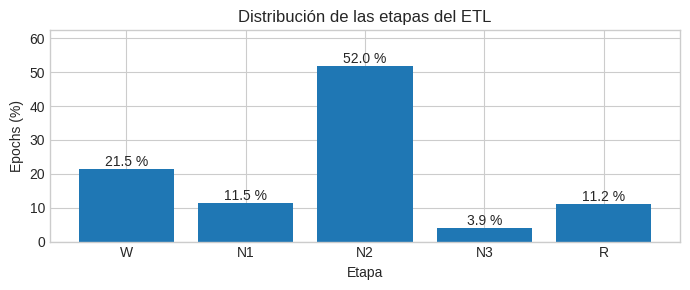

No se balancearon clases. En modelado, evaluar pesos solo en entrenamiento y métricas por etapa.


In [13]:
orden_etapas = ["W", "N1", "N2", "N3", "R"]
resumen_etapas = (
    df_epochs_all.groupby("Sleep_Stage", observed=True)
    .agg(epochs=("epoch", "size"), pacientes=("patient_id", "nunique"))
    .reindex(orden_etapas, fill_value=0)
)
resumen_etapas["porcentaje_epochs"] = 100 * resumen_etapas["epochs"] / len(df_epochs_all)
mostrar_tabla(resumen_etapas.round(2))
fig, ax = plt.subplots(figsize=(7, 3))
barras = ax.bar(resumen_etapas.index, resumen_etapas["porcentaje_epochs"])
ax.bar_label(barras, labels=[f"{v:.1f} %" for v in resumen_etapas["porcentaje_epochs"]])
ax.set(xlabel="Etapa", ylabel="Epochs (%)", title="Distribución de las etapas del ETL")
ax.set_ylim(0, max(1, resumen_etapas["porcentaje_epochs"].max() * 1.2))
fig.tight_layout()
plt.show()
print("No se balancearon clases. En modelado, evaluar pesos solo en entrenamiento y métricas por etapa.")


### 3.3.1. Candidatos atípicos: marcas, no descartes

Se marca un valor fuera de `Q1 − 1,5 × IQR` o `Q3 + 1,5 × IQR`, con cuartiles globales por variable. El porcentaje usa como denominador los epochs con valor finito. No mide errores confirmados.

Una señal puede tener muchos candidatos por asimetría, etapas o diferencias entre pacientes. Los vecinos y tramos son contiguos solo si sus tiempos están separados por 30 segundos.


In [14]:
# 3.3.1. Candidatos atípicos: marcas descriptivas, sin cambiar el dataset
variables_revision = [
    "HR_median", "HR_std", "TEMP_median", "EDA_median", "EDA_std",
    "BVP_std", "ACC_X_std", "ACC_Y_std", "ACC_Z_std",
] + [f"{senal}_std" for senal in psg_cols]
variables_revision = list(dict.fromkeys(
    col for col in variables_revision if col in df_epochs_all.columns
))
if not variables_revision:
    raise ValueError("No hay características disponibles para revisar atípicos.")

base_revision = df_epochs_all.sort_values(["patient_id", "tiempo_relativo_segundos"])
resumen_atipicos = []
resumen_atipicos_etapa = []
resumen_atipicos_paciente = []
casos_atipicos = []

for variable in variables_revision:
    valores = pd.to_numeric(base_revision[variable], errors="coerce")
    validos = valores.notna() & np.isfinite(valores)
    fila = {
        "variable": variable,
        "epochs_validos": int(validos.sum()),
        "epochs_sin_valor_finito": int((~validos).sum()),
    }
    if validos.sum() < 4:
        fila.update({"criterio": "insuficientes datos", "epochs_marcados": 0})
        resumen_atipicos.append(fila)
        continue

    q1, q3 = valores.loc[validos].quantile([0.25, 0.75])
    iqr = q3 - q1
    if not np.isfinite(iqr) or iqr == 0:
        fila.update({"criterio": "IQR nulo", "epochs_marcados": 0})
        resumen_atipicos.append(fila)
        continue

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    marcados = validos & (
        (valores < limite_inferior) | (valores > limite_superior)
    )
    fila.update({
        "criterio": "1,5 × IQR global",
        "minimo": valores.loc[validos].min(),
        "p01": valores.loc[validos].quantile(0.01),
        "mediana": valores.loc[validos].median(),
        "p99": valores.loc[validos].quantile(0.99),
        "maximo": valores.loc[validos].max(),
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "epochs_marcados": int(marcados.sum()),
        "porcentaje_epochs_marcados": 100 * marcados.sum() / validos.sum(),
        "pacientes_marcados": base_revision.loc[marcados, "patient_id"].nunique(),
    })
    resumen_atipicos.append(fila)

    por_paciente = (
        base_revision[["patient_id"]]
        .assign(epoch_valido=validos.astype(int), epoch_marcado=marcados.astype(int))
        .groupby("patient_id", sort=True)
        .sum()
    )
    por_paciente["variable"] = variable
    por_paciente["porcentaje_marcados"] = (
        100 * por_paciente["epoch_marcado"]
        / por_paciente["epoch_valido"].replace(0, np.nan)
    )
    resumen_atipicos_paciente.append(por_paciente.reset_index())

    for etapa in ["W", "N1", "N2", "N3", "R"]:
        en_etapa = base_revision["Sleep_Stage"].eq(etapa)
        n_validos = int((validos & en_etapa).sum())
        n_marcados = int((marcados & en_etapa).sum())
        resumen_atipicos_etapa.append({
            "variable": variable, "Sleep_Stage": etapa,
            "epochs_validos": n_validos,
            "epochs_marcados": n_marcados,
            "porcentaje_epochs_marcados": 100 * n_marcados / n_validos if n_validos else np.nan,
        })

    if not marcados.any():
        continue
    casos = base_revision.loc[
        marcados, ["patient_id", "epoch", "tiempo_relativo_segundos", "Sleep_Stage"]
    ].copy()
    casos["variable"] = variable
    casos["valor"] = valores.loc[marcados]
    casos["limite_inferior"] = limite_inferior
    casos["limite_superior"] = limite_superior
    casos["distancia_iqr"] = np.maximum(
        limite_inferior - casos["valor"],
        casos["valor"] - limite_superior,
    ) / iqr

    faltantes_col = variable.rsplit("_", 1)[0] + "_missing_frac"
    if faltantes_col in base_revision.columns:
        casos["fraccion_muestras_faltantes"] = base_revision.loc[
            marcados, faltantes_col
        ]

    grupos = base_revision["patient_id"]
    tiempos = base_revision["tiempo_relativo_segundos"]
    anterior_tiempo = tiempos.groupby(grupos).shift(1)
    siguiente_tiempo = tiempos.groupby(grupos).shift(-1)
    anterior = valores.groupby(grupos).shift(1).where(
        np.isclose(tiempos - anterior_tiempo, SEGUNDOS_EPOCH,
                   atol=TOLERANCIA_TIEMPO, rtol=0)
    )
    siguiente = valores.groupby(grupos).shift(-1).where(
        np.isclose(siguiente_tiempo - tiempos, SEGUNDOS_EPOCH,
                   atol=TOLERANCIA_TIEMPO, rtol=0)
    )
    casos["valor_epoch_anterior"] = anterior.loc[marcados]
    casos["valor_epoch_siguiente"] = siguiente.loc[marcados]
    casos_atipicos.append(casos)

resumen_atipicos = pd.DataFrame(resumen_atipicos)
resumen_atipicos_etapa = pd.DataFrame(resumen_atipicos_etapa)
resumen_atipicos_paciente = (
    pd.concat(resumen_atipicos_paciente, ignore_index=True)
    if resumen_atipicos_paciente else pd.DataFrame()
)
candidatos_atipicos = (
    pd.concat(casos_atipicos, ignore_index=True)
    if casos_atipicos else pd.DataFrame()
)

if candidatos_atipicos.empty:
    tramos_atipicos = pd.DataFrame()
else:
    ordenados = candidatos_atipicos.sort_values(
        ["variable", "patient_id", "tiempo_relativo_segundos"]
    ).copy()
    claves = [ordenados["variable"], ordenados["patient_id"]]
    separacion = ordenados.groupby(["variable", "patient_id"])["tiempo_relativo_segundos"].diff()
    nuevo_tramo = pd.Series(
        ~np.isclose(separacion, SEGUNDOS_EPOCH, atol=TOLERANCIA_TIEMPO, rtol=0),
        index=ordenados.index,
    )
    ordenados["tramo_id"] = nuevo_tramo.groupby(claves).cumsum()
    tramos_atipicos = (
        ordenados.groupby(["variable", "patient_id", "tramo_id"], sort=False)
        .agg(
            epoch_inicial=("epoch", "min"),
            epoch_final=("epoch", "max"),
            epochs_marcados=("epoch", "size"),
            distancia_iqr_max=("distancia_iqr", "max"),
        )
        .reset_index()
        .drop(columns="tramo_id")
    )
    tramos_atipicos["duracion_minutos"] = tramos_atipicos["epochs_marcados"] * 0.5

columnas_resumen = ["variable", "epochs_validos", "epochs_marcados",
                    "porcentaje_epochs_marcados", "pacientes_marcados"]
tabla_atipicos = resumen_atipicos.reindex(columns=columnas_resumen)
tabla_atipicos = tabla_atipicos.sort_values("epochs_marcados", ascending=False)
with pd.option_context("display.float_format", lambda v: f"{v:.6g}"):
    mostrar_tabla(tabla_atipicos)
    if MOSTRAR_DETALLE:
        mostrar_tabla(resumen_atipicos)
        mostrar_tabla(resumen_atipicos_etapa)
        mostrar_tabla(resumen_atipicos_paciente)
        mostrar_tabla(tramos_atipicos)
        mostrar_tabla(candidatos_atipicos)
print("Detalle disponible en las tablas de revisión. Ningún valor se eliminó ni recortó.")


,variable,epochs_validos,epochs_marcados,porcentaje_epochs_marcados,pacientes_marcados
4,EDA_std,56850,10007,17.6025,76
3,EDA_median,56850,8737,15.3685,34
6,ACC_X_std,56850,8635,15.1891,76
21,SNORE_std,56850,8573,15.08,62
20,RAT_std,56850,8413,14.7986,76
8,ACC_Z_std,56850,8107,14.2603,76
19,LAT_std,56850,7204,12.6719,76
7,ACC_Y_std,56850,6495,11.4248,76
11,O2-M1_std,56850,5874,10.3325,76
22,PTAF_std,56850,5504,9.68162,58


Detalle disponible en las tablas de revisión. Ningún valor se eliminó ni recortó.


### 3.3.2. Distribuciones de predictores

Cada punto analizado es el resumen de un epoch, no una muestra cruda. HR/TEMP describen niveles; BVP, ACC y EEG usan dispersión. Se muestran una sola vez sus cajas por etapa y las distribuciones globales más asimétricas.

Los boxplots ocultan los puntos fuera de los bigotes para leer las cajas; esos epochs permanecen en los datos. El detalle crudo individual aparece debajo.


Cobertura finita: 100 % en los seis predictores graficados.


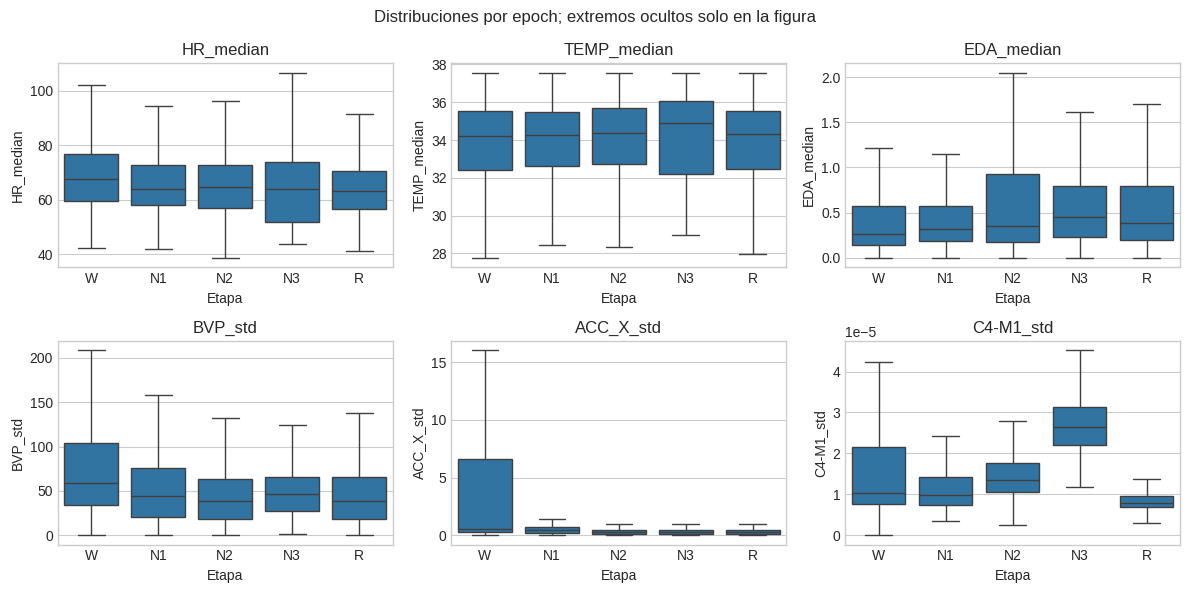

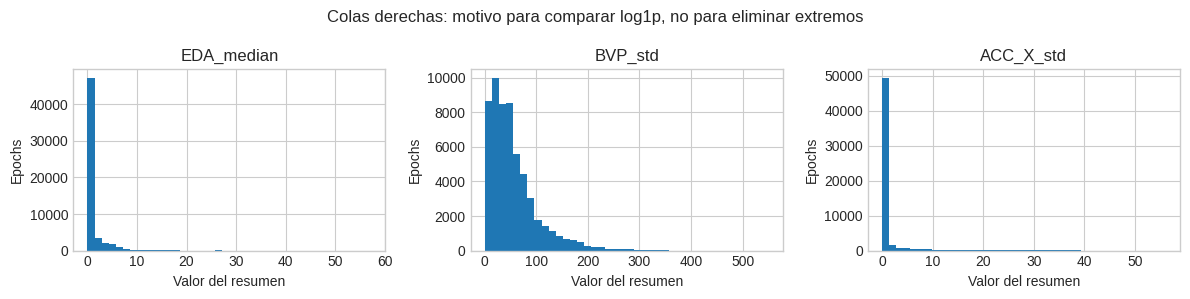

Solapamiento entre cajas: ninguna de estas vistas demuestra clasificación perfecta.


In [15]:
variables_distribucion = [
    "HR_median", "TEMP_median", "EDA_median", "BVP_std", "ACC_X_std", "C4-M1_std"
]
cobertura_predictores = pd.DataFrame([
    {"variable": c, "epochs_finitos": int(np.isfinite(df_epochs_all[c]).sum()),
     "cobertura_pct": 100 * np.isfinite(df_epochs_all[c]).mean()}
    for c in variables_distribucion
])
if MOSTRAR_DETALLE or cobertura_predictores["cobertura_pct"].lt(100).any():
    mostrar_tabla(cobertura_predictores)
else:
    print("Cobertura finita: 100 % en los seis predictores graficados.")

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, variable in zip(axes.flat, variables_distribucion):
    sns.boxplot(data=df_epochs_all, x="Sleep_Stage", y=variable,
                order=orden_etapas, showfliers=False, ax=ax)
    ax.set(title=variable, xlabel="Etapa", ylabel=variable)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 4), useOffset=False)
fig.suptitle("Distribuciones por epoch; extremos ocultos solo en la figura")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, variable in zip(axes, ["EDA_median", "BVP_std", "ACC_X_std"]):
    valores = pd.to_numeric(df_epochs_all[variable], errors="coerce")
    ax.hist(valores[np.isfinite(valores)], bins=40)
    ax.set(title=variable, xlabel="Valor del resumen", ylabel="Epochs")
fig.suptitle("Colas derechas: motivo para comparar log1p, no para eliminar extremos")
fig.tight_layout()
plt.show()
print("Solapamiento entre cajas: ninguna de estas vistas demuestra clasificación perfecta.")


#### Señales crudas: un paciente

Las cajas siguientes contienen hasta 1.500 muestras de 100 Hz por etapa de un paciente. No son medianas ni desviaciones de epochs, ni una comparación global. BVP crudo es una señal oscilatoria; su dispersión por epoch responde otra pregunta.


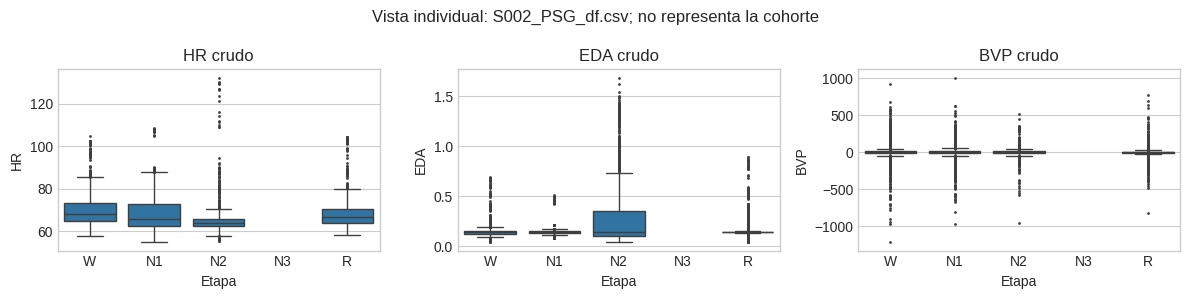

In [16]:
senales_crudas = ["HR", "EDA", "BVP"]
muestras_crudas = []
for etapa in orden_etapas:
    grupo = df_sample_eda.loc[df_sample_eda["Sleep_Stage"].eq(etapa)]
    if not grupo.empty:
        muestras_crudas.append(grupo.sample(n=min(1500, len(grupo)), random_state=42))
if muestras_crudas:
    vista_cruda = pd.concat(muestras_crudas, ignore_index=True)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    for ax, senal in zip(axes, senales_crudas):
        sns.boxplot(data=vista_cruda, x="Sleep_Stage", y=senal, order=orden_etapas,
                    showfliers=True, fliersize=1, ax=ax)
        ax.set(title=f"{senal} crudo", xlabel="Etapa", ylabel=senal)
    fig.suptitle(f"Vista individual: {sample_file.name}; no representa la cohorte")
    fig.tight_layout()
    plt.show()


### 3.3.3. EDA por paciente y tiempo

Los bloques coloreados resumen medianas de epochs conservados. Un bloque blanco significa que no hay un valor graficable en ese intervalo; no demuestra ausencia de EDA en el CSV crudo. S027/S048 deben contrastarse con sus intervalos excluidos.

S004/S057 mantienen marcas de revisión. El color de otros pacientes no certifica calidad. `log1p` se usa aquí únicamente para visualizar.


Archivos fuente: 77 | Pacientes incluidos en ETL: 76
Epochs sin EDA finita: 0 | Con EDA mediana negativa (revisar): 0
Pacientes con EDA resumida: 76


,patient_id,epochs_con_eda,mediana,p95,p99,estado_revision
28,57,762,0.2436,6.0686,31.4010,Pendiente de revisión
38,4,804,0.3218,45.2694,52.4887,Pendiente de revisión
58,48,677,0.6587,2.7721,3.2857,Exploratorio
73,27,532,5.2249,13.1697,30.5016,Exploratorio


Epochs con EDA pero tiempo no graficable: 0


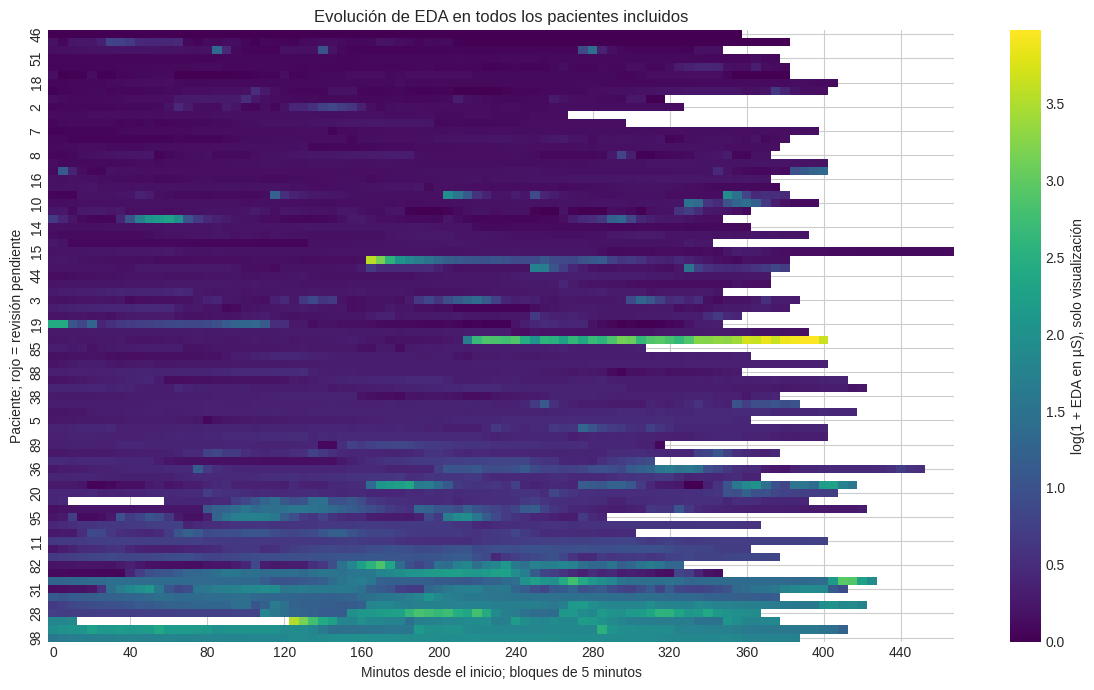

Gráficos descriptivos: no se recortó ni transformó el dataset.


In [17]:
# 3.3.3. Resumen EDA de todos los pacientes incluidos en el ETL
requeridas_eda = ["patient_id", "EDA_median", "tiempo_relativo_segundos"]
if not set(requeridas_eda).issubset(df_epochs_all.columns):
    raise ValueError("Faltan columnas para el análisis global de EDA.")
eda_total = df_epochs_all[requeridas_eda].copy()
for columna in ["EDA_median", "tiempo_relativo_segundos"]:
    eda_total[columna] = pd.to_numeric(eda_total[columna], errors="coerce")
finita = np.isfinite(eda_total["EDA_median"])
negativa = finita & eda_total["EDA_median"].lt(0)
print("Archivos fuente:", len(data_files),"| Pacientes incluidos en ETL:", eda_total["patient_id"].nunique())
print("Epochs sin EDA finita:", int((~finita).sum()),
      "| Con EDA mediana negativa (revisar):", int(negativa.sum()))
eda_valida = eda_total.loc[finita & ~negativa].copy()
if eda_valida.empty:
    raise ValueError("No hay EDA no negativa y finita para graficar.")
resumen_eda_paciente = eda_valida.groupby("patient_id")["EDA_median"].agg(
    epochs_con_eda="size", mediana="median",
    p95=lambda s: s.quantile(0.95), p99=lambda s: s.quantile(0.99),
    maximo_epoch="max",
).reset_index()
resumen_eda_paciente["epochs_totales"] = resumen_eda_paciente["patient_id"].map(
    eda_total.groupby("patient_id").size()
)
resumen_eda_paciente["cobertura_pct"] = (
    100 * resumen_eda_paciente["epochs_con_eda"]
    / resumen_eda_paciente["epochs_totales"]
)
resumen_eda_paciente["estado_revision"] = np.where(
    resumen_eda_paciente["patient_id"].isin([4, 57]),
    "Pendiente de revisión", "Exploratorio",
)
resumen_eda_paciente = resumen_eda_paciente.sort_values("mediana").reset_index(drop=True)
print("Pacientes con EDA resumida:", len(resumen_eda_paciente))
mostrar_tabla(resumen_eda_paciente.loc[
    resumen_eda_paciente["patient_id"].isin([4, 27, 48, 57])
].round(4), ["patient_id", "epochs_con_eda", "mediana", "p95", "p99", "estado_revision"])
if MOSTRAR_DETALLE:
    mostrar_tabla(resumen_eda_paciente.round(4))

tiempo_valido = (np.isfinite(eda_valida["tiempo_relativo_segundos"])
                 & eda_valida["tiempo_relativo_segundos"].ge(0))
print("Epochs con EDA pero tiempo no graficable:", int((~tiempo_valido).sum()))
eda_temporal = eda_valida.loc[tiempo_valido].copy()
if not eda_temporal.empty:
    eda_temporal["bloque_5min"] = (
        eda_temporal["tiempo_relativo_segundos"] // 300
    ).astype(int)
    mapa_eda = eda_temporal.groupby(["patient_id", "bloque_5min"])["EDA_median"].median().unstack()
    mapa_eda = mapa_eda.reindex(resumen_eda_paciente["patient_id"])
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.heatmap(np.log1p(mapa_eda), ax=ax, cmap="viridis", yticklabels=max(1, len(mapa_eda) // 20),
                cbar_kws={"label": "log(1 + EDA en µS), solo visualización"})
    paso = max(1, int(np.ceil(len(mapa_eda.columns) / 12)))
    indices = np.arange(0, len(mapa_eda.columns), paso)
    ax.set_xticks(indices + 0.5)
    ax.set_xticklabels((mapa_eda.columns[indices] * 5).astype(int), rotation=0)
    for etiqueta in ax.get_yticklabels():
        if etiqueta.get_text() in {"4", "57"}:
            etiqueta.set_color("tab:red")
    ax.set(xlabel="Minutos desde el inicio; bloques de 5 minutos",
           ylabel="Paciente; rojo = revisión pendiente",
           title="Evolución de EDA en todos los pacientes incluidos")
    plt.tight_layout()
    plt.show()
print("Gráficos descriptivos: no se recortó ni transformó el dataset.")


## 3.4. Relaciones entre predictores

Spearman describe cómo cambian conjuntamente dos variables. Se muestran todos los pares de los 26 predictores originales priorizados: nueve del wearable y 17 de PSG. No son todas las columnas del ETL: se excluyen identificadores, tiempo, objetivo, marcas de calidad y resúmenes que no forman parte de esta selección.

El mapa general incluye relaciones wearable–wearable, PSG–PSG y wearable–PSG. Rojo indica asociación positiva; azul, negativa; tonos claros, valores próximos a cero. La escala es fija entre −1 y 1. El triángulo vacío evita repetir pares y la diagonal; las celdas grises del triángulo visible indican correlaciones no evaluables.

El filtro `|Spearman| > 0,85` ya contempla ambos signos. Se conserva como resumen de relaciones muy intensas, pero no reemplaza el mapa general. Se agregan las cinco relaciones más negativas, aun si no superan ese umbral. Cada correlación exige al menos 30 epochs con valores finitos comunes; una variable constante no tiene correlación definida.

Los pares altamente correlacionados se conservarán hasta compararlos mediante ablación: entrenar con y sin un canal bajo las mismas particiones. Este análisis reúne epochs de todos los pacientes y no modifica datos ni demuestra causalidad o prescindibilidad predictiva.


Correlaciones: 56,850 epochs | 76 pacientes | 26 predictores originales (9 wearable y 17 PSG).
Se excluyen ID, epoch, tiempo, objetivo y metadatos de calidad. Gris: correlación no evaluable por constancia o cobertura insuficiente.


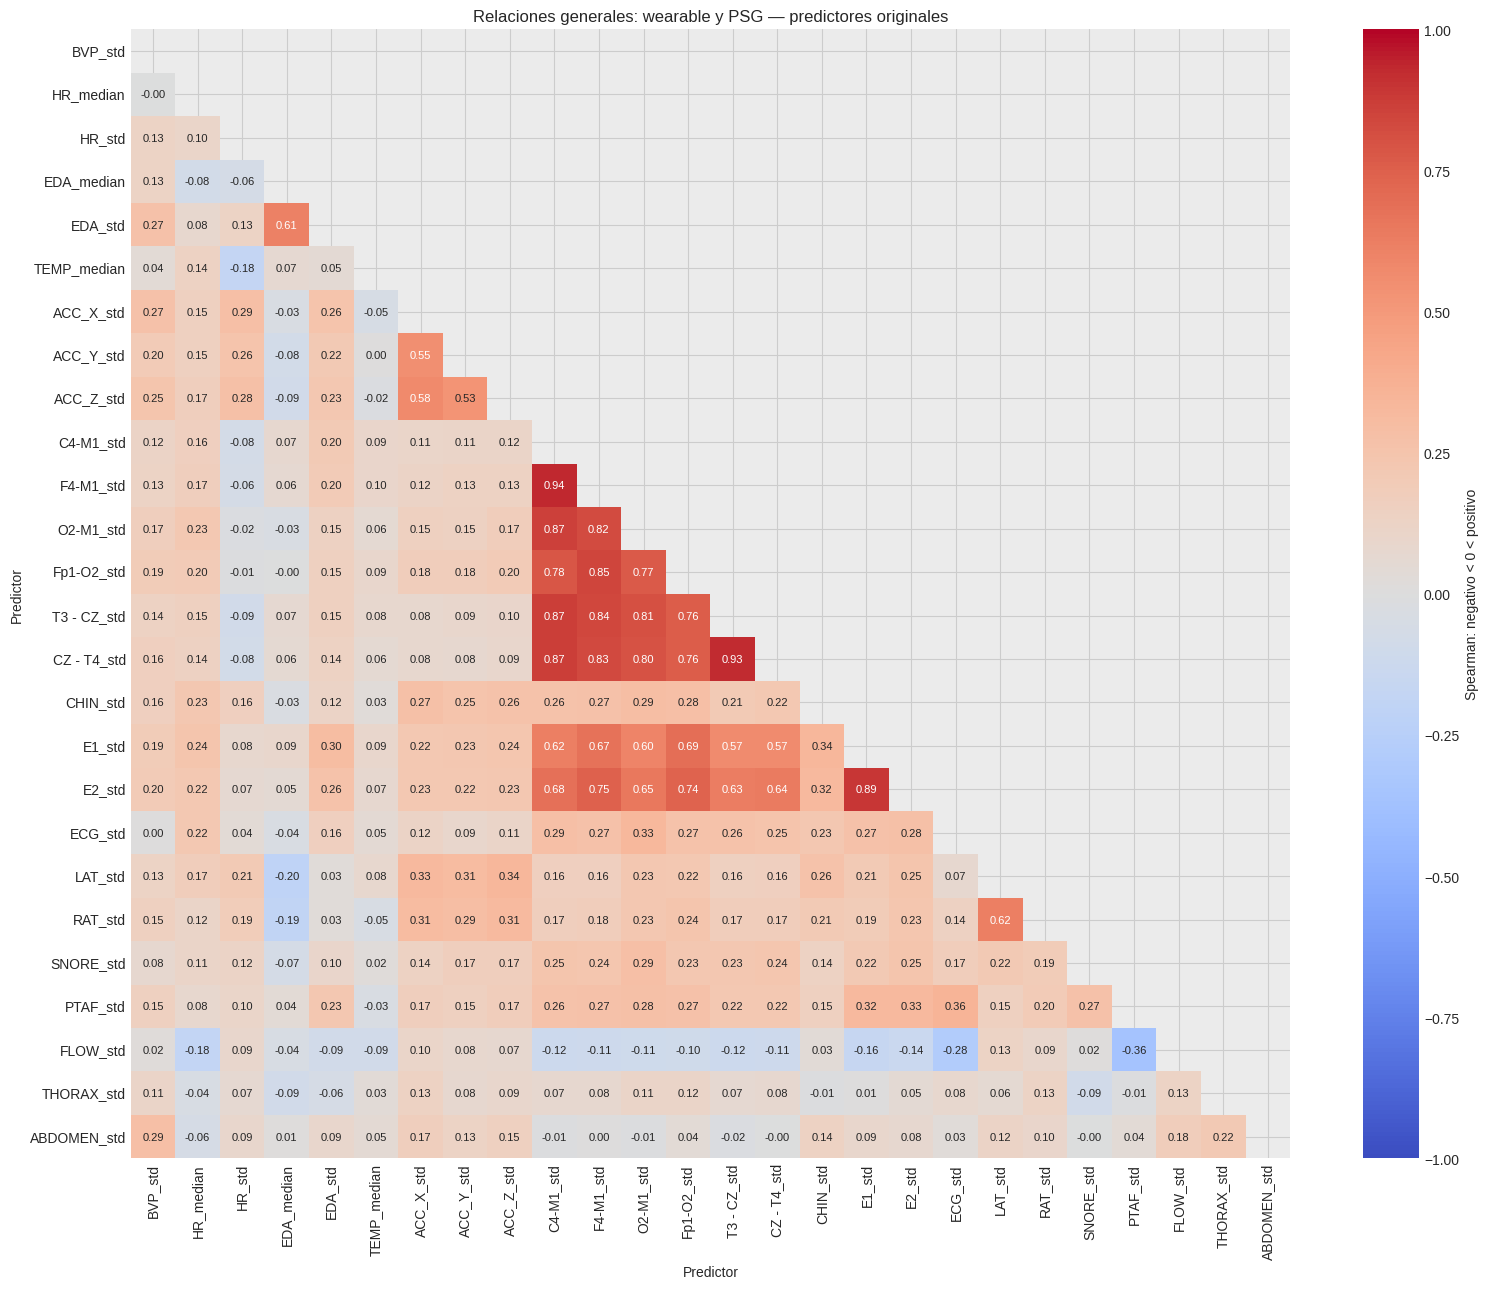

Pares con |Spearman| > 0,85: 6; ninguno se elimina


,variable_1,variable_2,spearman,n_epochs_comunes
0,C4-M1_std,F4-M1_std,0.9363,56850
1,T3 - CZ_std,CZ - T4_std,0.9251,56850
2,E1_std,E2_std,0.8949,56850
3,C4-M1_std,T3 - CZ_std,0.8749,56850
4,C4-M1_std,CZ - T4_std,0.8717,56850
5,C4-M1_std,O2-M1_std,0.8672,56850


Cinco relaciones más negativas; se muestran aunque |Spearman| no supere 0,85.


,variable_1,variable_2,spearman,n_epochs_comunes
0,PTAF_std,FLOW_std,-0.3617,56850
1,ECG_std,FLOW_std,-0.2828,56850
2,EDA_median,LAT_std,-0.2035,56850
3,EDA_median,RAT_std,-0.1883,56850
4,HR_median,FLOW_std,-0.1807,56850


In [18]:
# 3.4. Relaciones generales entre predictores originales, sin variable objetivo
if "df_epochs_all" not in globals() or df_epochs_all.empty:
    raise ValueError("Falta df_epochs_all. Ejecutar primero la sección 3.1.")

columnas_centrales = ["HR_median", "EDA_median", "TEMP_median"]
faltantes_centrales = [c for c in columnas_centrales if c not in df_epochs_all.columns]
if faltantes_centrales:
    raise ValueError(f"Faltan columnas esperadas del ETL: {faltantes_centrales}")

wearable_mapa = [c for c in [
    "BVP_std", "HR_median", "HR_std", "EDA_median", "EDA_std",
    "TEMP_median", "ACC_X_std", "ACC_Y_std", "ACC_Z_std",
] if c in df_epochs_all.columns]
psg_mapa = [f"{senal}_std" for senal in psg_cols
            if f"{senal}_std" in df_epochs_all.columns]
caracteristicas_asociacion = wearable_mapa + psg_mapa
if len(caracteristicas_asociacion) < 2:
    raise ValueError("Faltan características para calcular asociaciones.")

# Solo una vista numérica: no se cambia el ETL ni se imputan los valores no finitos.
MIN_EPOCHS_CORRELACION = 30
datos_correlacion = df_epochs_all[caracteristicas_asociacion].apply(
    pd.to_numeric, errors="coerce"
).replace([np.inf, -np.inf], np.nan)
corr_predictores = datos_correlacion.corr(
    method="spearman", min_periods=MIN_EPOCHS_CORRELACION
)
valores_finitos_correlacion = datos_correlacion.notna().astype("int64")
epochs_comunes_correlacion = (
    valores_finitos_correlacion.T @ valores_finitos_correlacion
)
print(
    f"Correlaciones: {len(df_epochs_all):,} epochs | "
    f"{df_epochs_all['patient_id'].nunique()} pacientes | "
    f"{len(caracteristicas_asociacion)} predictores originales "
    f"({len(wearable_mapa)} wearable y {len(psg_mapa)} PSG)."
)
print(
    "Se excluyen ID, epoch, tiempo, objetivo y metadatos de calidad. "
    "Gris: correlación no evaluable por constancia o cobertura insuficiente."
)

# El mapa muestra todos los pares evaluables, no solamente los de magnitud alta.
fig, ax = plt.subplots(figsize=(16, 13))
ax.set_facecolor("0.92")
sns.heatmap(
    corr_predictores,
    mask=np.triu(np.ones(corr_predictores.shape, dtype=bool)),
    annot=True, fmt=".2f", annot_kws={"size": 8},
    cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax,
    cbar_kws={"label": "Spearman: negativo < 0 < positivo"},
)
ax.set_title("Relaciones generales: wearable y PSG — predictores originales")
ax.set_xlabel("Predictor")
ax.set_ylabel("Predictor")
ax.tick_params(axis="x", rotation=90)
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()
plt.show()

triangulo = corr_predictores.where(np.triu(np.ones(
    corr_predictores.shape, dtype=bool), k=1))
pares_correlacion = (
    triangulo.stack().dropna().rename("spearman").reset_index()
    .rename(columns={"level_0": "variable_1", "level_1": "variable_2"})
)
pares_correlacion["magnitud"] = pares_correlacion["spearman"].abs()
pares_correlacion["n_epochs_comunes"] = [
    int(epochs_comunes_correlacion.loc[a, b])
    for a, b in zip(pares_correlacion["variable_1"], pares_correlacion["variable_2"])
]
pares_revisar = (
    pares_correlacion.loc[pares_correlacion["magnitud"].gt(0.85)]
    .sort_values("magnitud", ascending=False).reset_index(drop=True)
)
print(f"Pares con |Spearman| > 0,85: {len(pares_revisar)}; ninguno se elimina")
columnas_pares_correlacion = [
    "variable_1", "variable_2", "spearman", "n_epochs_comunes"
]
mostrar_tabla(pares_revisar.round(4), columnas_pares_correlacion)

pares_negativos = (
    pares_correlacion.loc[pares_correlacion["spearman"].lt(0)]
    .sort_values("spearman").head(5).reset_index(drop=True)
)
if pares_negativos.empty:
    print("No hay pares negativos evaluables en estos predictores.")
else:
    print("Cinco relaciones más negativas; se muestran aunque |Spearman| no supere 0,85.")
    mostrar_tabla(pares_negativos.round(4), columnas_pares_correlacion)
if MOSTRAR_DETALLE:
    mostrar_tabla(
        pares_correlacion.sort_values("magnitud", ascending=False).round(4),
        columnas_pares_correlacion
    )


### Correlación entre wearable y PSG

Cada fila del mapa corresponde a un predictor del wearable; cada columna, a un predictor PSG. Se incluyen los nueve predictores wearable y los 17 PSG disponibles, no una selección de los pares más correlacionados.

La escala conserva el signo: positivo significa que los valores tienden a aumentar juntos; negativo, que uno tiende a disminuir cuando el otro aumenta. Cerca de cero significa poca asociación monotónica, no independencia ni falta de utilidad para clasificar.

El resumen identifica el par positivo y el negativo de mayor magnitud del cruce, junto con los epochs válidos comunes. Es descriptivo: reunir epochs de distintos pacientes puede mezclar diferencias entre personas, etapas y tiempo. Ni una correlación alta demuestra que un wearable sustituya al PSG ni una baja justifica descartar una variable.

Los nuevos mapas requieren ejecutar nuevamente 3.4 sobre el ETL completo. Las salidas conservadas del resto del notebook corresponden a 77 archivos, 76 pacientes y 56.850 epochs.


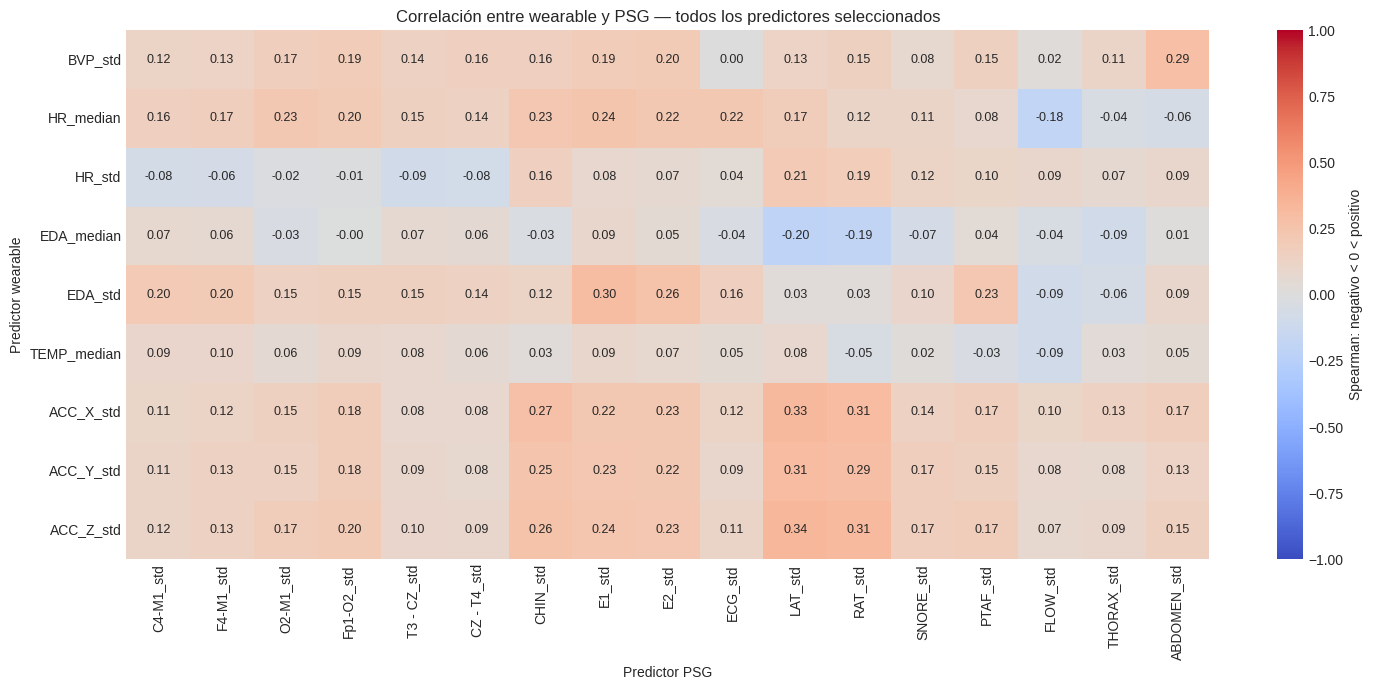

,relacion,variable_1,variable_2,spearman,n_epochs_comunes
0,positiva más intensa,ACC_Z_std,LAT_std,0.3377,56850
1,negativa más intensa,EDA_median,LAT_std,-0.2035,56850


Conclusión: el signo describe la dirección conjunta; la magnitud describe la asociación monotónica. No demuestra causalidad ni reemplazo de sensores. Contrastar por paciente y mediante ablación antes de eliminar predictores.


In [19]:
# 3.4. Cruce completo wearable–PSG, conservando signo y cobertura
corr_wearable = corr_predictores.loc[wearable_mapa, wearable_mapa]
corr_cruce = corr_predictores.loc[wearable_mapa, psg_mapa]
if wearable_mapa and psg_mapa:
    fig, ax = plt.subplots(figsize=(15, 7))
    ax.set_facecolor("0.92")
    sns.heatmap(
        corr_cruce, annot=True, fmt=".2f", annot_kws={"size": 9},
        cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax,
        cbar_kws={"label": "Spearman: negativo < 0 < positivo"},
    )
    ax.set_title("Correlación entre wearable y PSG — todos los predictores seleccionados")
    ax.set_xlabel("Predictor PSG")
    ax.set_ylabel("Predictor wearable")
    ax.tick_params(axis="x", rotation=90)
    ax.tick_params(axis="y", rotation=0)
    fig.tight_layout()
    plt.show()

    pares_cruce = (
        pares_correlacion.loc[
            pares_correlacion["variable_1"].isin(wearable_mapa)
            & pares_correlacion["variable_2"].isin(psg_mapa)
        ].copy()
    )
    resumen_cruce = pd.concat([
        pares_cruce.loc[pares_cruce["spearman"].gt(0)]
            .nlargest(1, "spearman").assign(relacion="positiva más intensa"),
        pares_cruce.loc[pares_cruce["spearman"].lt(0)]
            .nsmallest(1, "spearman").assign(relacion="negativa más intensa"),
    ], ignore_index=True)
    if resumen_cruce.empty:
        print("No hay correlaciones cruzadas distintas de cero evaluables.")
    else:
        mostrar_tabla(
            resumen_cruce.round(4),
            ["relacion", *columnas_pares_correlacion]
        )
    print(
        "Conclusión: el signo describe la dirección conjunta; la magnitud describe "
        "la asociación monotónica. No demuestra causalidad ni reemplazo de sensores. "
        "Contrastar por paciente y mediante ablación antes de eliminar predictores."
    )
else:
    print("Faltan predictores wearable o PSG para construir el cruce.")


### 3.4.1. Asociación descriptiva con las etapas

Cada celda compara una etapa contra todas las demás usando `2 × AUC de rangos − 1`. Positivo: valores mayores en esa etapa. Negativo: menores. Cerca de cero: poca separación univariada.

No es exactitud de un clasificador ni evaluación en pacientes nuevos. La consistencia dentro de pacientes se resume en 3.5.


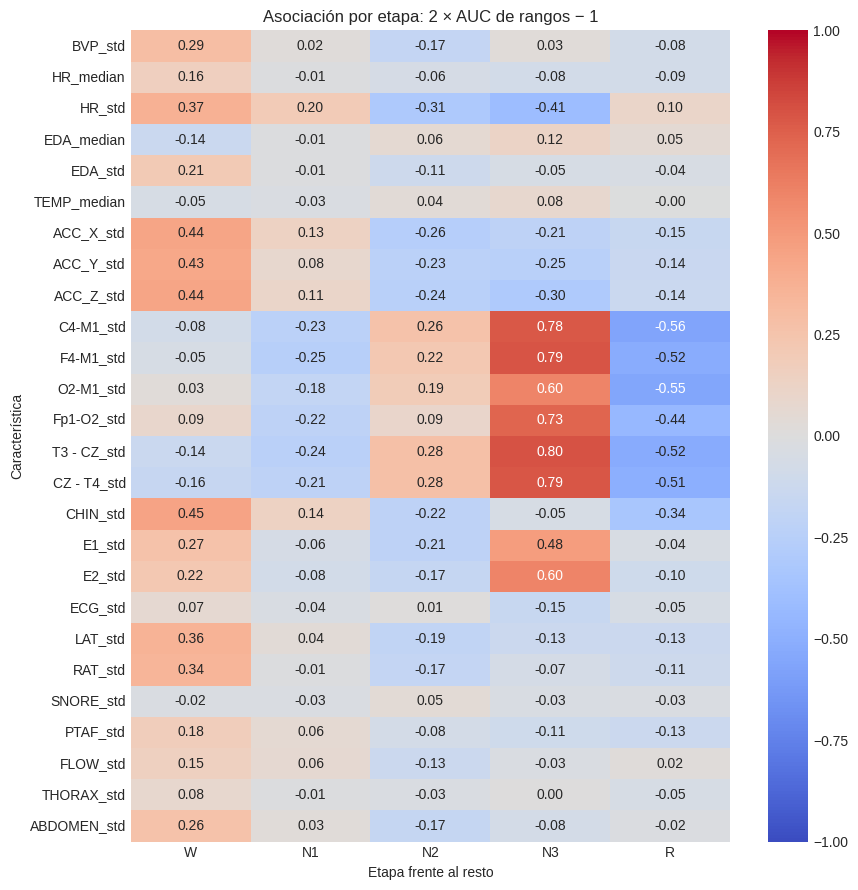

0: sin separación univariada; positivo: valores mayores en la etapa; negativo: valores menores. Revisar cobertura y consistencia entre pacientes. Estas AUC no son rendimiento predictivo fuera de muestra.


In [20]:
# 3.4.1. Asociación por etapa: AUC de rangos uno contra el resto
orden_etapas = ["W", "N1", "N2", "N3", "R"]
if not df_epochs_all["Sleep_Stage"].isin(orden_etapas).all():
    raise ValueError("Hay etapas inválidas o faltantes.")

filas_auc = []
for variable in caracteristicas_asociacion:
    valores = pd.to_numeric(df_epochs_all[variable], errors="coerce")
    validos = valores.notna() & np.isfinite(valores)
    rangos = valores.loc[validos].rank(method="average")
    etapas_validas = df_epochs_all.loc[validos, "Sleep_Stage"]
    for etapa in orden_etapas:
        positivos = etapas_validas.eq(etapa)
        n_pos = int(positivos.sum())
        n_neg = int((~positivos).sum())
        auc = (
            (rangos.loc[positivos].sum() - n_pos * (n_pos + 1) / 2)
            / (n_pos * n_neg)
            if n_pos and n_neg else np.nan
        )
        filas_auc.append({
            "variable": variable, "Sleep_Stage": etapa,
            "auc_rangos": auc,
            "direccion": 2 * auc - 1 if pd.notna(auc) else np.nan,
            "epochs_etapa": n_pos, "epochs_resto": n_neg,
            "cobertura_pct": 100 * validos.mean(),
            "pacientes_etapa": df_epochs_all.loc[
                validos & df_epochs_all["Sleep_Stage"].eq(etapa), "patient_id"
            ].nunique(),
        })

resumen_auc_etapa = pd.DataFrame(filas_auc)
matriz_direccion = resumen_auc_etapa.pivot(
    index="variable", columns="Sleep_Stage", values="direccion"
).reindex(index=caracteristicas_asociacion, columns=orden_etapas)
if matriz_direccion.notna().any().any():
    plt.figure(figsize=(9, 9))
    sns.heatmap(matriz_direccion, annot=True, fmt=".2f",
                cmap="coolwarm", center=0, vmin=-1, vmax=1)
    plt.title("Asociación por etapa: 2 × AUC de rangos − 1")
    plt.xlabel("Etapa frente al resto")
    plt.ylabel("Característica")
    plt.tight_layout()
    plt.show()
else:
    print("No hay etapas con ambos grupos para calcular AUC de rangos.")

if MOSTRAR_DETALLE:
    mostrar_tabla(resumen_auc_etapa.round(3))
print(
    "0: sin separación univariada; positivo: valores mayores en la etapa; "
    "negativo: valores menores. Revisar cobertura y consistencia entre pacientes. "
    "Estas AUC no son rendimiento predictivo fuera de muestra."
)


### 3.4.2. Tiempo y etapa

Usar `tiempo_relativo_segundos`, medido desde el inicio del CSV, no desde el inicio clínico del sueño. Comparar la distribución por bloques y la dirección dentro de cada paciente.

- Proporción global: pesan más los pacientes con más epochs válidos en ese bloque.
- Promedio individual: cada paciente observado pesa igual en el bloque.
- Cobertura: cuántos pacientes aportan al bloque. En los extremos tardíos, pocos pacientes pueden cambiar mucho las proporciones.

AUC temporal menor que 0,5 indica una etapa relativamente temprana; mayor que 0,5, tardía. Solo son evaluables los pacientes con al menos cinco epochs de la etapa y cinco del resto.


In [21]:
# 3.4.2. Tiempo frente a etapa: análisis global y dentro de pacientes
BLOQUE_TIEMPO_MINUTOS = 30
MIN_EPOCHS_TIEMPO_POR_GRUPO = 5
orden_etapas_tiempo = ["W", "N1", "N2", "N3", "R"]


def auc_tiempo_rangos(valores, positivos, min_epochs=1):
    """Probabilidad de mayor tiempo en la etapa, contando empates como 0,5."""
    valores = pd.Series(np.asarray(valores, dtype=float))
    positivos = pd.Series(np.asarray(positivos, dtype=bool))
    if len(valores) != len(positivos) or not np.isfinite(valores).all():
        raise ValueError("AUC temporal: longitudes distintas o tiempos no finitos.")
    n_pos, n_neg = int(positivos.sum()), int((~positivos).sum())
    if n_pos < min_epochs or n_neg < min_epochs:
        return np.nan
    rangos = valores.rank(method="average")
    return float(
        (rangos.loc[positivos].sum() - n_pos * (n_pos + 1) / 2)
        / (n_pos * n_neg)
    )


def analizar_tiempo_etapas(datos, bloque_minutos=30, min_epochs=5):
    """Construir vistas descriptivas sin modificar datos ni comprimir huecos."""
    columnas = ["patient_id", "epoch", "Sleep_Stage", "tiempo_relativo_segundos"]
    if datos.empty or not set(columnas).issubset(datos.columns):
        raise ValueError("Falta un dataset de epochs no vacío con tiempo relativo.")
    if not np.isfinite(bloque_minutos) or bloque_minutos <= 0 or min_epochs < 1:
        raise ValueError("El bloque y el mínimo de epochs deben ser positivos.")
    if datos[["patient_id", "epoch"]].isna().any().any():
        raise ValueError("Hay identidades paciente/epoch faltantes.")
    if datos.duplicated(["patient_id", "epoch"]).any():
        raise ValueError("Hay identidades paciente/epoch repetidas.")

    etapas = ["W", "N1", "N2", "N3", "R"]
    temporal = datos[columnas].copy()
    temporal["tiempo_relativo_segundos"] = pd.to_numeric(
        temporal["tiempo_relativo_segundos"], errors="coerce"
    )
    etapa_valida = temporal["Sleep_Stage"].isin(etapas)
    tiempo_valido = (
        np.isfinite(temporal["tiempo_relativo_segundos"])
        & temporal["tiempo_relativo_segundos"].ge(0)
    )
    cobertura = {
        "epochs_dataset": len(datos),
        "pacientes_dataset": datos["patient_id"].nunique(),
        "epochs_etapa_invalida": int((~etapa_valida).sum()),
        # Exclusiones disjuntas: se cuenta el tiempo inválido solo con etapa válida.
        "epochs_tiempo_invalido": int((etapa_valida & ~tiempo_valido).sum()),
    }
    temporal = temporal.loc[etapa_valida & tiempo_valido].copy()
    if temporal.empty:
        raise ValueError("No hay epochs con etapa válida y tiempo finito no negativo.")
    if temporal.duplicated(["patient_id", "tiempo_relativo_segundos"]).any():
        raise ValueError("Un mismo instante se repite dentro de un paciente.")
    temporal["tiempo_minutos"] = temporal["tiempo_relativo_segundos"] / 60
    cobertura.update({
        "epochs_analizados": len(temporal),
        "pacientes_analizados": temporal["patient_id"].nunique(),
        "cobertura_epochs_pct": 100 * len(temporal) / len(datos),
    })

    filas_globales, filas_paciente = [], []
    for etapa in etapas:
        positivos = temporal["Sleep_Stage"].eq(etapa)
        tiempos_etapa = temporal.loc[positivos, "tiempo_minutos"]
        auc = auc_tiempo_rangos(temporal["tiempo_minutos"], positivos)
        filas_globales.append({
            "Sleep_Stage": etapa,
            "epochs_etapa": int(positivos.sum()),
            "epochs_resto": int((~positivos).sum()),
            "pacientes_con_etapa": temporal.loc[positivos, "patient_id"].nunique(),
            "p25_minutos": tiempos_etapa.quantile(0.25),
            "mediana_minutos": tiempos_etapa.median(),
            "p75_minutos": tiempos_etapa.quantile(0.75),
            "auc_global": auc,
            "direccion_global": 2 * auc - 1,
        })
    for paciente, grupo in temporal.groupby("patient_id", sort=True):
        for etapa in etapas:
            positivos = grupo["Sleep_Stage"].eq(etapa)
            n_pos, n_neg = int(positivos.sum()), int((~positivos).sum())
            auc = auc_tiempo_rangos(grupo["tiempo_minutos"], positivos, min_epochs)
            filas_paciente.append({
                "patient_id": paciente, "Sleep_Stage": etapa,
                "epochs_etapa": n_pos, "epochs_resto": n_neg,
                "auc_rangos": auc, "direccion": 2 * auc - 1,
                "estado": "evaluable" if pd.notna(auc) else "pocos epochs o etapa ausente",
            })
    globales = pd.DataFrame(filas_globales)
    por_paciente = pd.DataFrame(filas_paciente)
    filas_estabilidad = []
    for etapa in etapas:
        aucs = por_paciente.loc[
            por_paciente["Sleep_Stage"].eq(etapa), "auc_rangos"
        ].dropna()
        filas_estabilidad.append({
            "Sleep_Stage": etapa, "pacientes_evaluables": len(aucs),
            "auc_paciente_p25": aucs.quantile(0.25),
            "auc_paciente_mediana": aucs.median(),
            "auc_paciente_p75": aucs.quantile(0.75),
            "pacientes_auc_mayor_05_pct": 100 * aucs.gt(0.5).mean() if len(aucs) else np.nan,
        })
    resumen = globales.merge(pd.DataFrame(filas_estabilidad), on="Sleep_Stage")

    # Intervalos [inicio, fin), referidos al CSV; epoch no se usa como reloj.
    temporal["bloque_temporal"] = (
        temporal["tiempo_relativo_segundos"] // (bloque_minutos * 60)
    ).astype(int)
    indice_bloques = pd.RangeIndex(
        int(temporal["bloque_temporal"].max()) + 1, name="bloque_temporal"
    )
    conteos = (
        temporal.groupby(["bloque_temporal", "Sleep_Stage"], observed=True)
        .size().unstack(fill_value=0)
        .reindex(index=indice_bloques, columns=etapas, fill_value=0)
    )
    proporciones_globales = (
        100 * conteos.div(conteos.sum(axis=1).replace(0, np.nan), axis=0)
    )
    conteos_paciente = (
        temporal.groupby(["bloque_temporal", "patient_id", "Sleep_Stage"], observed=True)
        .size().unstack(fill_value=0).reindex(columns=etapas, fill_value=0)
    )
    # Las etapas ausentes valen 0 solo donde ese paciente sí tiene observaciones.
    porcentajes_paciente = 100 * conteos_paciente.div(
        conteos_paciente.sum(axis=1), axis=0
    )
    proporciones_pacientes = (
        porcentajes_paciente.groupby(level="bloque_temporal").mean()
        .reindex(indice_bloques)
    )
    cobertura_bloques = pd.DataFrame({
        "inicio_minutos": indice_bloques * bloque_minutos,
        "fin_minutos": (indice_bloques + 1) * bloque_minutos,
        "epochs": conteos.sum(axis=1),
        "pacientes": temporal.groupby("bloque_temporal")["patient_id"]
            .nunique().reindex(indice_bloques, fill_value=0),
    })
    return {
        "datos": temporal, "cobertura": cobertura, "resumen": resumen,
        "por_paciente": por_paciente, "proporciones_globales": proporciones_globales,
        "proporciones_pacientes": proporciones_pacientes,
        "cobertura_bloques": cobertura_bloques,
    }


if "df_epochs_all" not in globals():
    raise ValueError("Ejecutar primero 3.1 o cargar su caché validada.")
huella_base_tiempo = pd.util.hash_pandas_object(df_epochs_all, index=True).copy()
resultado_tiempo = analizar_tiempo_etapas(
    df_epochs_all, BLOQUE_TIEMPO_MINUTOS, MIN_EPOCHS_TIEMPO_POR_GRUPO
)
resumen_tiempo_etapa = resultado_tiempo["resumen"]
auc_tiempo_por_paciente = resultado_tiempo["por_paciente"]
matriz_auc_tiempo = auc_tiempo_por_paciente.pivot(
    index="patient_id", columns="Sleep_Stage", values="auc_rangos"
).reindex(columns=orden_etapas_tiempo)
mostrar_tabla(pd.DataFrame([resultado_tiempo["cobertura"]]).round(2))
mostrar_tabla(resumen_tiempo_etapa.round(3), [
    "Sleep_Stage", "mediana_minutos", "pacientes_evaluables",
    "auc_paciente_mediana", "pacientes_auc_mayor_05_pct"
])
for clave in ["proporciones_globales", "proporciones_pacientes"]:
    observados = resultado_tiempo["cobertura_bloques"]["epochs"].gt(0)
    if not np.allclose(resultado_tiempo[clave].loc[observados].sum(axis=1), 100):
        raise ValueError("Las proporciones temporales no suman 100 %.")
if not huella_base_tiempo.equals(pd.util.hash_pandas_object(df_epochs_all, index=True)):
    raise ValueError("El análisis temporal modificó el ETL base.")
if MOSTRAR_DETALLE:
    mostrar_tabla(matriz_auc_tiempo.round(3))
    mostrar_tabla(resultado_tiempo["cobertura_bloques"])


,epochs_dataset,pacientes_dataset,epochs_etapa_invalida,epochs_tiempo_invalido,epochs_analizados,pacientes_analizados,cobertura_epochs_pct
0,56850,76,0,0,56850,76,100.0


,Sleep_Stage,mediana_minutos,pacientes_evaluables,auc_paciente_mediana,pacientes_auc_mayor_05_pct
0,W,192.133,75,0.505,52.000
1,N1,196.000,76,0.517,55.263
2,N2,179.500,76,0.460,34.211
3,N3,86.492,27,0.227,3.704
4,R,261.133,64,0.663,85.938


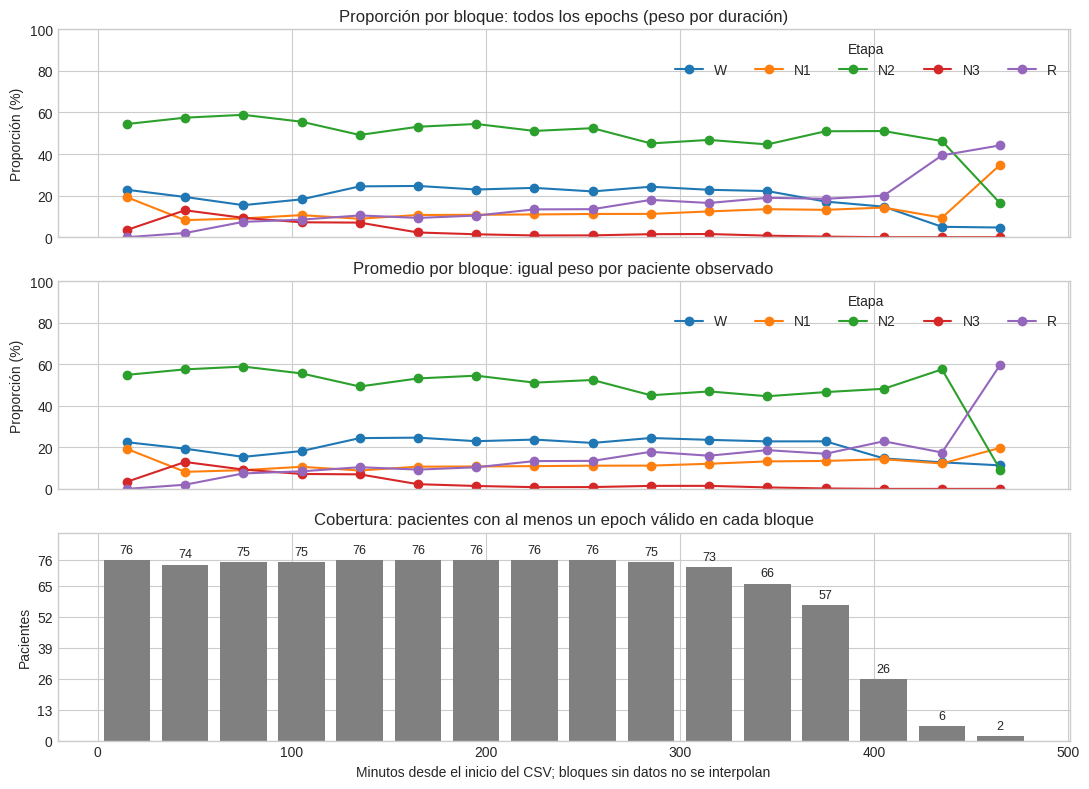

In [22]:
# 3.4.2. Gráficos temporales; sin entrenar modelos ni transformar predictores
paleta_tiempo = dict(zip(orden_etapas_tiempo, sns.color_palette("tab10", 5)))
if MOSTRAR_DIAGNOSTICOS:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(
        data=resultado_tiempo["datos"], x="Sleep_Stage", y="tiempo_minutos",
        order=orden_etapas_tiempo, color="steelblue", showfliers=True, ax=ax
    )
    ax.set_title("Distribución del tiempo por etapa — todos los epochs analizados")
    ax.set_xlabel("Etapa del sueño")
    ax.set_ylabel("Minutos desde el inicio del CSV")
    fig.tight_layout()
    plt.show()

    if matriz_auc_tiempo.notna().any().any():
        fig, ax = plt.subplots(figsize=(8, max(4, 0.25 * len(matriz_auc_tiempo))))
        ax.set_facecolor("0.92")
        sns.heatmap(
            matriz_auc_tiempo, annot=len(matriz_auc_tiempo) <= 100, fmt=".2f",
            cmap="coolwarm", center=0.5, vmin=0, vmax=1, ax=ax,
            cbar_kws={"label": "AUC de rangos: temprano < 0,5 < tardío"}
        )
        ax.set_title("Tiempo–etapa dentro de cada paciente; gris = no evaluable")
        ax.set_xlabel("Etapa frente al resto")
        ax.set_ylabel("Paciente")
        fig.tight_layout()
        plt.show()
    else:
        print("Ningún paciente tiene suficientes epochs en ambos grupos para la AUC.")


fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
cobertura_bloques_tiempo = resultado_tiempo["cobertura_bloques"]
centros_minutos = (
    cobertura_bloques_tiempo["inicio_minutos"]
    + cobertura_bloques_tiempo["fin_minutos"]
) / 2
for ax, clave, titulo in [
    (axes[0], "proporciones_globales", "Proporción por bloque: todos los epochs (peso por duración)"),
    (axes[1], "proporciones_pacientes", "Promedio por bloque: igual peso por paciente observado"),
]:
    for etapa in orden_etapas_tiempo:
        ax.plot(centros_minutos, resultado_tiempo[clave][etapa],
                marker="o", color=paleta_tiempo[etapa], label=etapa)
    ax.set_title(titulo)
    ax.set_ylabel("Proporción (%)")
    ax.set_ylim(0, 100)
    ax.legend(ncol=5, title="Etapa", loc="upper right")
barras_cobertura = axes[2].bar(
    centros_minutos, cobertura_bloques_tiempo["pacientes"],
    width=BLOQUE_TIEMPO_MINUTOS * 0.8, color="0.5"
)
# Conteos discretos: marcas enteras, adaptadas a la cohorte, y etiquetas por barra.
max_pacientes_bloque = int(cobertura_bloques_tiempo["pacientes"].max())
paso_pacientes = max(1, int(np.ceil(max_pacientes_bloque / 6)))
marcas_pacientes = np.arange(0, max_pacientes_bloque + 1, paso_pacientes)
if marcas_pacientes[-1] != max_pacientes_bloque:
    marcas_pacientes = np.append(marcas_pacientes, max_pacientes_bloque)
axes[2].set_yticks(marcas_pacientes)
axes[2].set_ylim(0, max(1, max_pacientes_bloque * 1.15))
axes[2].bar_label(
    barras_cobertura,
    labels=[str(int(n)) for n in cobertura_bloques_tiempo["pacientes"]],
    padding=3, fontsize=9,
)
axes[2].set_title("Cobertura: pacientes con al menos un epoch válido en cada bloque")
axes[2].set_ylabel("Pacientes")
axes[2].set_xlabel("Minutos desde el inicio del CSV; bloques sin datos no se interpolan")
fig.tight_layout()
plt.show()


#### Conclusión temporal

Consultar la mediana de AUC y el porcentaje de pacientes con la misma dirección antes de generalizar. REM tiende a observarse más tarde y N3 más temprano en la ejecución de referencia; existen excepciones y pacientes no evaluables.

El tiempo puede aportar contexto, pero no reemplaza las señales. Su valor predictivo debe compararse después, con y sin tiempo, validando por paciente. No extrapolar los últimos bloques sin revisar su cobertura.


## 3.5. Decisiones sobre características

Conservar solo una ficha de decisiones y un resumen de consistencia. No seleccionar variables por una tabla de asociación aislada. Las comparaciones predictivas y las ablaciones quedan para la sección 4.


### 3.5.1. Consistencia entre pacientes

Comparar, dentro de cada paciente, la mediana de una variable en una etapa contra la mediana del resto. Informar cuántos pacientes son evaluables y qué porcentaje presenta diferencia positiva.

Esta vista reduce la confusión entre diferencias de personas y de etapas. Diferencias pequeñas requieren precisión numérica; un resultado descriptivo no demuestra utilidad predictiva.


In [23]:
# 3.5.1. Ficha descriptiva de características y estabilidad entre pacientes
if "resumen_auc_etapa" not in globals():
    raise ValueError("Ejecutar primero el mapa de asociación de la sección 3.4.")

variables_estabilidad = [c for c in [
    "HR_median", "TEMP_median", "EDA_median", "BVP_std",
    "ACC_X_std", "C4-M1_std", "E1_std", "FLOW_std",
] if c in df_epochs_all.columns]
min_epochs_comparacion = 5
filas_estabilidad = []
for variable in variables_estabilidad:
    datos = df_epochs_all[["patient_id", "Sleep_Stage", variable]].copy()
    datos[variable] = pd.to_numeric(datos[variable], errors="coerce")
    datos = datos.loc[np.isfinite(datos[variable])]
    for etapa in ["W", "N1", "N2", "N3", "R"]:
        en_etapa = datos["Sleep_Stage"].eq(etapa)
        dentro = datos.loc[en_etapa].groupby("patient_id")[variable].agg(
            mediana_etapa="median", epochs_etapa="size"
        )
        fuera = datos.loc[~en_etapa].groupby("patient_id")[variable].agg(
            mediana_resto="median", epochs_resto="size"
        )
        pares = dentro.join(fuera, how="inner")
        pares = pares.loc[
            pares["epochs_etapa"].ge(min_epochs_comparacion)
            & pares["epochs_resto"].ge(min_epochs_comparacion)
        ]
        diferencias = pares["mediana_etapa"] - pares["mediana_resto"]
        filas_estabilidad.append({
            "variable": variable, "Sleep_Stage": etapa,
            "pacientes_evaluables": len(pares),
            "mediana_diferencia": diferencias.median() if len(pares) else np.nan,
            "pacientes_diferencia_positiva_pct":
                100 * diferencias.gt(0).mean() if len(pares) else np.nan,
        })
resumen_estabilidad = pd.DataFrame(filas_estabilidad)
matriz_estabilidad = resumen_estabilidad.pivot(
    index="variable", columns="Sleep_Stage",
    values="pacientes_diferencia_positiva_pct"
).reindex(columns=["W", "N1", "N2", "N3", "R"])
mostrar_tabla(matriz_estabilidad.round(1))
mostrar_tabla(resumen_estabilidad.groupby("Sleep_Stage")
              ["pacientes_evaluables"].agg(["min", "max"]).reindex(orden_etapas))
if MOSTRAR_DETALLE:
    with pd.option_context("display.float_format", lambda v: f"{v:.6g}"):
        mostrar_tabla(resumen_estabilidad)
print("Porcentajes próximos a 50 %: dirección poco consistente entre pacientes; no implican inutilidad multivariada.")


Sleep_Stage,W,N1,N2,N3,R
variable,,,,,
ACC_X_std,97.3,57.9,11.8,37.0,40.6
BVP_std,86.7,38.2,28.9,55.6,37.5
C4-M1_std,50.7,13.2,80.3,100.0,3.1
E1_std,82.7,31.6,30.3,92.6,45.3
EDA_median,44.0,46.1,48.7,51.9,53.1
FLOW_std,78.7,56.6,27.6,40.7,43.8
HR_median,85.3,48.7,22.4,59.3,51.6
TEMP_median,42.7,39.5,46.1,74.1,48.4


,min,max
Sleep_Stage,,
W,75,75
N1,76,76
N2,76,76
N3,27,27
R,64,64


Porcentajes próximos a 50 %: dirección poco consistente entre pacientes; no implican inutilidad multivariada.


### 3.5.2. Representaciones candidatas

| Grupo | Candidato inicial | Motivo y alternativa |
| --- | --- | --- |
| HR/TEMP | Mediana; conservar HR_std | Nivel y variación. Comparar otros resúmenes si aportan mejora. |
| BVP/EDA | log1p(BVP_std), log1p(EDA_median); conservar EDA_std | Comprimir colas sin recortar. Comparar con valores originales. |
| Ojos/piernas | Máximo bilateral de desviaciones | Resume mayor actividad; puede perder diferencias entre lados. Comparar canales separados. |
| ACC | Norma de desviaciones X/Y/Z y log1p | Resumir dispersión de tres ejes; no equivale a std de la norma de la señal cruda. |
| PSG correlacionadas | Conservar | Correlación alta no prueba que un canal sea prescindible para N3/R. |
| Metadatos | Conservar fuera de X | ID y epoch permiten rastrear observaciones. Tiempo se probará como predictor después. |

Las fórmulas siguientes construyen copias sin modificar el dataset base. Se mantiene la capacidad de comparación futura, pero no se despliegan 14 experimentos sin evaluación.


In [24]:
# 3.5.2. Definiciones de conjuntos de predictores; sin editar el dataset base
wearable_base = [
    "HR_median", "HR_std", "TEMP_median", "EDA_median", "EDA_std",
    "BVP_std", "ACC_X_std", "ACC_Y_std", "ACC_Z_std",
]
psg_std_base = [
    "C4-M1_std", "F4-M1_std", "O2-M1_std", "Fp1-O2_std",
    "T3 - CZ_std", "CZ - T4_std", "CHIN_std", "E1_std", "E2_std",
    "ECG_std", "LAT_std", "RAT_std", "SNORE_std", "PTAF_std",
    "FLOW_std", "THORAX_std", "ABDOMEN_std",
]
faltantes_base = set(wearable_base + psg_std_base + ["Sleep_Stage", "patient_id"]) - set(df_epochs_all.columns)
if faltantes_base:
    raise ValueError(f"Faltan columnas para las comparaciones: {sorted(faltantes_base)}")

def construir_predictores(escenario, variante, datos):
    # Construye una copia temporal para una comparación; no altera datos.
    columnas = wearable_base + (psg_std_base if escenario == "PSG + wearable" else [])
    if escenario not in {"PSG + wearable", "wearable solo"}:
        raise ValueError(f"Escenario desconocido: {escenario}")
    x = datos.loc[:, columnas].apply(pd.to_numeric, errors="coerce").copy()
    if not np.isfinite(x.to_numpy(dtype=float)).all():
        raise ValueError("Hay predictores no finitos; revisar calidad antes de comparar.")
    if variante == "log1p_colas":
        colas = ["BVP_std", "EDA_median", "ACC_X_std", "ACC_Y_std", "ACC_Z_std"]
        if x[colas].lt(0).any().any():
            raise ValueError("log1p requiere variables no negativas en esta prueba.")
        x.loc[:, colas] = np.log1p(x[colas])
    elif variante == "ojos_maximo":
        x["EOG_max_std"] = x[["E1_std", "E2_std"]].max(axis=1)
        x = x.drop(columns=["E1_std", "E2_std"])
    elif variante == "piernas_maximo":
        x["LEG_max_std"] = x[["LAT_std", "RAT_std"]].max(axis=1)
        x = x.drop(columns=["LAT_std", "RAT_std"])
    elif variante == "acc_norma":
        ejes = ["ACC_X_std", "ACC_Y_std", "ACC_Z_std"]
        x["ACC_axes_std_norm"] = np.sqrt(x[ejes].pow(2).sum(axis=1))
        x = x.drop(columns=ejes)
    elif variante == "combinada_candidata":
        if escenario == "PSG + wearable":
            x["EOG_max_std"] = x[["E1_std", "E2_std"]].max(axis=1)
            x["LEG_max_std"] = x[["LAT_std", "RAT_std"]].max(axis=1)
            x = x.drop(columns=["E1_std", "E2_std", "LAT_std", "RAT_std"])
        ejes = ["ACC_X_std", "ACC_Y_std", "ACC_Z_std"]
        x["ACC_axes_std_norm"] = np.sqrt(x[ejes].pow(2).sum(axis=1))
        x = x.drop(columns=ejes)
        por_log = ["BVP_std", "EDA_median", "ACC_axes_std_norm"]
        if x[por_log].lt(0).any().any():
            raise ValueError("La candidata combinada exige entradas no negativas.")
        for columna in por_log:
            x[f"{columna}_log1p"] = np.log1p(x[columna])
        x = x.drop(columns=por_log)
    elif variante.startswith("sin_"):
        columna = variante.removeprefix("sin_")
        if columna not in x:
            raise ValueError(f"No se puede retirar {columna} del escenario {escenario}.")
        x = x.drop(columns=[columna])
    elif variante != "original":
        raise ValueError(f"Variante desconocida: {variante}")
    return x


## 3.6. Variación entre pacientes

Cada proporción se calcula dentro de un paciente y después se resume entre pacientes. No es una evolución temporal ni la proporción global de todos los epochs.

Duración válida cuenta epochs; tramo observado y latencia REM usan el tiempo real. Los huecos no se comprimen. La latencia se mide desde el primer sueño observado; no equivale a una medición clínica completa.


PACIENTES RESUMIDOS: 76
SIN REM OBSERVADO: 12
SIN N3 OBSERVADO: 40
RESUMEN ENTRE PACIENTES (cuantiles de la tabla completa)


,indicador,pacientes_con_dato,p25,mediana,p75
0,Epochs válidos por paciente,76,713.00,758.50,803.25
1,Duración válida (min),76,356.50,379.25,401.62
2,Tramo observado (min),76,360.25,379.75,401.62
3,Huecos temporales,76,0.00,0.00,0.00
4,Transiciones contiguas,76,89.50,121.00,161.25
5,Latencia REM observada (min),64,77.25,114.25,188.62
6,Proporción W (%),76,7.68,16.60,31.26
7,Proporción N1 (%),76,5.55,8.33,15.37
8,Proporción N2 (%),76,46.11,53.14,60.95
9,Proporción N3 (%),76,0.00,0.00,6.25


Latencias REM con huecos: 1


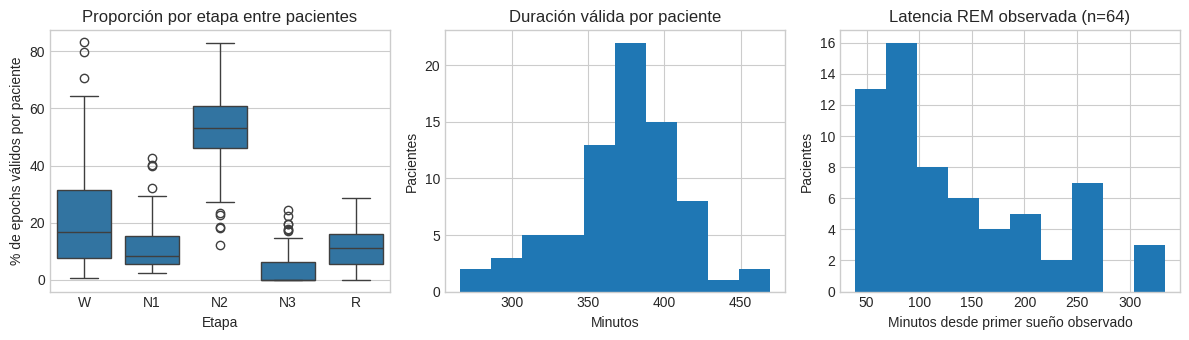

Los gráficos muestran variación descriptiva, no calidad del sueño ni un criterio de exclusión de pacientes.


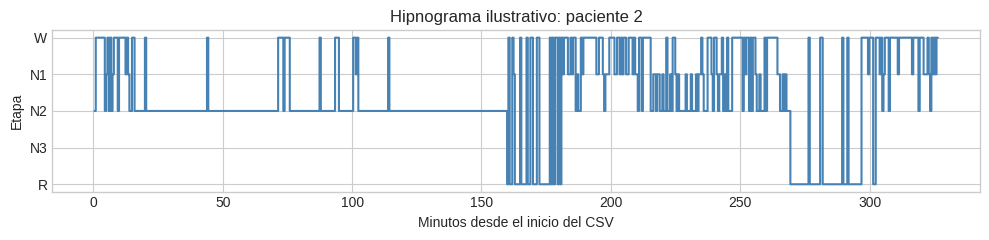

In [25]:
# 3.6. Resumen descriptivo de etapas por paciente
orden_etapas = ["W", "N1", "N2", "N3", "R"]
if "df_epochs_all" not in globals() or df_epochs_all.empty:
    raise ValueError("Falta el dataset consolidado de epochs.")
if df_epochs_all.duplicated(["patient_id", "epoch"]).any():
    raise ValueError("Hay claves paciente/epoch duplicadas.")
if not df_epochs_all["Sleep_Stage"].isin(orden_etapas).all():
    raise ValueError("Hay etapas faltantes o inválidas.")

resumen_filas = []
for patient_id, grupo in df_epochs_all.groupby("patient_id", sort=True):
    grupo = grupo.sort_values("tiempo_relativo_segundos")
    conteos = grupo["Sleep_Stage"].value_counts().reindex(
        orden_etapas, fill_value=0
    )
    primer_sueno = grupo.loc[
        grupo["Sleep_Stage"].ne("W"), "tiempo_relativo_segundos"
    ].min()
    primer_rem = grupo.loc[
        grupo["Sleep_Stage"].eq("R"), "tiempo_relativo_segundos"
    ].min()
    latencia_rem = (
        (primer_rem - primer_sueno) / 60
        if pd.notna(primer_sueno) and pd.notna(primer_rem) else np.nan
    )
    tiempos = pd.to_numeric(grupo["tiempo_relativo_segundos"], errors="coerce")
    if not (np.isfinite(tiempos).all() and tiempos.ge(0).all()):
        raise ValueError("Hay tiempos relativos inválidos.")
    diferencias_tiempo = tiempos.diff()
    if diferencias_tiempo.dropna().lt(SEGUNDOS_EPOCH - TOLERANCIA_TIEMPO).any():
        raise ValueError("Hay epochs temporalmente solapados.")
    contiguos = continuidad_temporal(tiempos)

    transiciones = int((
        contiguos
        & grupo["Sleep_Stage"].ne(grupo["Sleep_Stage"].shift())
    ).sum())
    fila = {
        "patient_id": patient_id,
        "epochs_validos": len(grupo),
        "duracion_valida_min": len(grupo) * 0.5,
        "tramo_observado_min":
            (tiempos.max() - tiempos.min() + SEGUNDOS_EPOCH) / 60,
        "huecos_temporales": int(diferencias_tiempo.gt(SEGUNDOS_EPOCH + TOLERANCIA_TIEMPO).sum()),
        "transiciones_contiguas": transiciones,
        "etapas_ausentes": ", ".join(conteos.index[conteos.eq(0)]) or "ninguna",
        "estado_rem": "observado" if pd.notna(primer_rem) else "no observado",
        "latencia_rem_desde_primer_sueno_min": latencia_rem,
        "latencia_rem_con_huecos": bool((diferencias_tiempo.gt(SEGUNDOS_EPOCH + TOLERANCIA_TIEMPO) & tiempos.gt(primer_sueno) & tiempos.le(primer_rem)).any()) if pd.notna(latencia_rem) else False,
    }
    for etapa in orden_etapas:
        fila[f"epochs_{etapa}"] = int(conteos[etapa])
        fila[f"pct_{etapa}"] = 100 * conteos[etapa] / len(grupo)
    for calidad in ["HR_missing_frac", "BVP_missing_frac", "C4-M1_missing_frac"]:
        if calidad in grupo.columns:
            fila[f"{calidad}_promedio"] = grupo[calidad].mean()
    resumen_filas.append(fila)

resumen_pacientes = pd.DataFrame(resumen_filas).sort_values(
    "patient_id"
).reset_index(drop=True)
if "auditoria_epochs" in globals():
    columnas_auditoria = [c for c in [
        "patient_id", "filas_fragmento_inicial", "filas_fragmento_final",
        "epochs_descartados_por_pureza", "continuidad_temporal",
    ] if c in auditoria_epochs.columns]
    if "patient_id" in columnas_auditoria:
        resumen_pacientes = resumen_pacientes.merge(
            auditoria_epochs[columnas_auditoria], on="patient_id",
            how="left", validate="one_to_one",
        )

print("PACIENTES RESUMIDOS:", len(resumen_pacientes))
print("SIN REM OBSERVADO:", resumen_pacientes["epochs_R"].eq(0).sum())
print("SIN N3 OBSERVADO:", resumen_pacientes["epochs_N3"].eq(0).sum())
metricas_resumen_36 = {
    "Epochs válidos por paciente": "epochs_validos",
    "Duración válida (min)": "duracion_valida_min",
    "Tramo observado (min)": "tramo_observado_min",
    "Huecos temporales": "huecos_temporales",
    "Transiciones contiguas": "transiciones_contiguas",
    "Latencia REM observada (min)": "latencia_rem_desde_primer_sueno_min",
    **{f"Proporción {e} (%)": f"pct_{e}" for e in orden_etapas},
}
filas_resumen_36 = []
for indicador, columna in metricas_resumen_36.items():
    valores = pd.to_numeric(resumen_pacientes[columna], errors="coerce").dropna()
    filas_resumen_36.append({
        "indicador": indicador, "pacientes_con_dato": len(valores),
        "mínimo": valores.min(), "p25": valores.quantile(0.25),
        "mediana": valores.median(), "p75": valores.quantile(0.75),
        "máximo": valores.max(),
    })
resumen_global_36 = pd.DataFrame(filas_resumen_36)
print("RESUMEN ENTRE PACIENTES (cuantiles de la tabla completa)")
mostrar_tabla(resumen_global_36.round(2), ["indicador", "pacientes_con_dato", "p25", "mediana", "p75"])
if MOSTRAR_DETALLE:
    mostrar_tabla(resumen_pacientes)
print("Latencias REM con huecos:", int(resumen_pacientes["latencia_rem_con_huecos"].sum()))

proporciones = resumen_pacientes.melt(
    id_vars="patient_id", value_vars=[f"pct_{e}" for e in orden_etapas],
    var_name="etapa", value_name="porcentaje_epochs",
)
proporciones["etapa"] = proporciones["etapa"].str.removeprefix("pct_")
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
sns.boxplot(data=proporciones, x="etapa", y="porcentaje_epochs",
            order=orden_etapas, ax=axes[0], showfliers=True)
axes[0].set_title("Proporción por etapa entre pacientes")
axes[0].set_xlabel("Etapa")
axes[0].set_ylabel("% de epochs válidos por paciente")
axes[1].hist(resumen_pacientes["duracion_valida_min"].dropna())
axes[1].set_title("Duración válida por paciente")
axes[1].set_xlabel("Minutos")
axes[1].set_ylabel("Pacientes")
latencias_rem = resumen_pacientes[
    "latencia_rem_desde_primer_sueno_min"
].dropna()
if not latencias_rem.empty:
    axes[2].hist(latencias_rem)
axes[2].set_title(f"Latencia REM observada (n={len(latencias_rem)})")
axes[2].set_xlabel("Minutos desde primer sueño observado")
axes[2].set_ylabel("Pacientes")
plt.tight_layout()
plt.show()
print(
    "Los gráficos muestran variación descriptiva, no calidad del sueño "
    "ni un criterio de exclusión de pacientes."
)

# Ejemplo del ETL; los huecos se dibujan como segmentos separados.
paciente_ilustrativo = extract_patient_id(sample_file)
hipnograma = df_epochs_all.loc[
    df_epochs_all["patient_id"].eq(paciente_ilustrativo)
].sort_values("tiempo_relativo_segundos").copy()
if not hipnograma.empty:
    hipnograma["segmento"] = (~continuidad_temporal(hipnograma["tiempo_relativo_segundos"])).cumsum()
    fig, ax = plt.subplots(figsize=(10, 2.5))
    for _, segmento in hipnograma.groupby("segmento"):
        x = segmento["tiempo_relativo_segundos"].to_numpy()
        y = segmento["Sleep_Stage"].map(dict(zip(orden_etapas, range(5)))).to_numpy()
        ax.step(np.r_[x, x[-1] + SEGUNDOS_EPOCH] / 60,
                np.r_[y, y[-1]], where="post", color="steelblue")
    ax.set_yticks(range(5), orden_etapas)
    ax.set(title=f"Hipnograma ilustrativo: paciente {paciente_ilustrativo}",
           xlabel="Minutos desde el inicio del CSV", ylabel="Etapa")
    ax.invert_yaxis()
    fig.tight_layout()
    plt.show()


#### Lectura y conclusión

En el boxplot, cada paciente aporta una proporción por etapa. La caja contiene la mitad central de los pacientes; la línea es su mediana. Una etapa ausente aporta 0 %, no un dato faltante. Esto muestra heterogeneidad, no la secuencia de la noche.

Los histogramas cuentan pacientes por duración válida o latencia observada. La latencia solo incluye quienes tienen REM registrado. No usar estas figuras como diagnóstico clínico ni para excluir pacientes automáticamente.


## 3.7. Controles lógicos del ETL

Verificar etiquetas, claves, desviaciones no negativas, recuentos y fracciones coherentes. Estos controles no fijan límites fisiológicos ni reparan sensores. Las incidencias quedan disponibles para rastrear; una violación lógica detiene el flujo.


In [26]:
# 3.7. Controles lógicos de rangos, sin recorte
if "df_epochs_all" not in globals() or df_epochs_all.empty:
    raise ValueError("Falta el dataset de epochs.")

reglas_rango = []
for col in df_epochs_all.columns:
    if col.endswith("_std"):
        reglas_rango.append((col, "desviación estándar negativa",
                             lambda v: v.lt(0)))
    elif col.endswith("_n_valid"):
        reglas_rango.append((col, "recuento fuera de [0, 3000] o no entero",
                             lambda v: v.lt(0) | v.gt(3000) | v.ne(v.round())))
    elif col.endswith("_missing_frac") or col in {"porcentaje_pureza", "porcentaje_pureza_original"}:
        reglas_rango.append((col, "fracción fuera de [0, 1]",
                             lambda v: v.lt(0) | v.gt(1)))

filas_controles = []
casos_controles = []
for variable, regla, criterio in reglas_rango:
    valores = pd.to_numeric(df_epochs_all[variable], errors="coerce")
    definidos = valores.notna()
    infraccion = definidos & (~np.isfinite(valores) | criterio(valores))
    filas_controles.append({
        "variable": variable, "regla": regla,
        "epochs_afectados": int(infraccion.sum()),
        "pacientes_afectados": df_epochs_all.loc[
            infraccion, "patient_id"
        ].nunique(),
        "epochs_sin_valor": int((~definidos).sum()),
    })
    if infraccion.any():
        casos = df_epochs_all.loc[
            infraccion, ["patient_id", "epoch", "Sleep_Stage"]
        ].copy()
        casos["variable"] = variable
        casos["regla"] = regla
        casos["valor"] = valores.loc[infraccion]
        casos_controles.append(casos)

for senal in [c.removesuffix("_n_valid") for c in df_epochs_all.columns
              if c.endswith("_n_valid")]:
    n_valid = pd.to_numeric(df_epochs_all[f"{senal}_n_valid"], errors="coerce")
    faltantes = pd.to_numeric(
        df_epochs_all[f"{senal}_missing_frac"], errors="coerce"
    )
    comparables = np.isfinite(n_valid) & np.isfinite(faltantes)
    infraccion = comparables & (
        faltantes.sub(1 - n_valid / 3000).abs().gt(1e-4)
    )
    filas_controles.append({
        "variable": senal,
        "regla": "recuento y fracción de faltantes inconsistentes",
        "epochs_afectados": int(infraccion.sum()),
        "pacientes_afectados": df_epochs_all.loc[
            infraccion, "patient_id"
        ].nunique(),
        "epochs_sin_valor": int((~comparables).sum()),
    })
    if infraccion.any():
        casos = df_epochs_all.loc[
            infraccion, ["patient_id", "epoch", "Sleep_Stage"]
        ].copy()
        casos["variable"] = senal
        casos["regla"] = "recuento y fracción de faltantes inconsistentes"
        casos["valor"] = faltantes.loc[infraccion]
        casos_controles.append(casos)

resumen_controles_rango = pd.DataFrame(filas_controles)
casos_controles_rango = (
    pd.concat(casos_controles, ignore_index=True)
    if casos_controles else pd.DataFrame(columns=[
        "patient_id", "epoch", "Sleep_Stage", "variable", "regla", "valor"
    ])
)
mostrar_tabla(pd.DataFrame([
    {"control": "Rangos y coherencia de recuentos", "reglas_evaluadas": len(resumen_controles_rango),
     "incidencias": int(resumen_controles_rango["epochs_afectados"].sum())},
    {"control": "Etapas válidas", "reglas_evaluadas": 1,
     "incidencias": int((~df_epochs_all["Sleep_Stage"].isin(orden_etapas)).sum())},
]))
violaciones = resumen_controles_rango.loc[resumen_controles_rango["epochs_afectados"].gt(0)]
if MOSTRAR_DETALLE or not violaciones.empty:
    mostrar_tabla(violaciones)
    mostrar_tabla(casos_controles_rango)
if not violaciones.empty:
    raise ValueError("Hay violaciones lógicas: revisar los casos antes de transformar.")
if not df_epochs_all["Sleep_Stage"].isin(orden_etapas).all():
    raise ValueError("Hay etiquetas inválidas.")
validar_tabla_csv(df_epochs_all, rutas_etl["dataset"])
if not np.isclose(resumen_pacientes["duracion_valida_min"].sum(),
                  len(df_epochs_all) * SEGUNDOS_EPOCH / 60):
    raise ValueError("La duración válida no concilia con los epochs.")
if resumen_pacientes["tramo_observado_min"].lt(
    resumen_pacientes["duracion_valida_min"] - TOLERANCIA_TIEMPO
).any():
    raise ValueError("El tramo observado es menor que la duración válida.")
if not np.allclose(resumen_pacientes[[f"pct_{e}" for e in orden_etapas]].sum(axis=1), 100):
    raise ValueError("Las proporciones por paciente no suman 100 %.")
print("Controles lógicos aprobados; no certifican calidad instrumental ni utilidad predictiva.")


,control,reglas_evaluadas,incidencias
0,Rangos y coherencia de recuentos,98,0
1,Etapas válidas,1,0


Controles lógicos aprobados; no certifican calidad instrumental ni utilidad predictiva.


## 3.8. Síntesis antes de transformar

La ficha de 3.2 identifica la ejecución cargada y debe coincidir con **77 archivos, 76 pacientes y 56.850 epochs**. Las conclusiones no usan salidas de otras cohortes.

El ETL conserva estadísticas, metadatos y trazabilidad. Se analizaron calidad, desbalance, distribuciones, candidatos atípicos, asociaciones, consistencia entre pacientes y relación temporal. La regla IQR y los máximos no justifican un recorte global.

Pendientes instrumentales: segmentos de S027/S048, EDA elevada de S004/S057/S027, TEMP baja y escala/calidad de SAO2/IBI. Mantener marcas; corregir solo un defecto localizado y confirmado.

La sección siguiente construye una copia candidata sin cambiar el ETL base ni sus clases. Sus controles verifican integridad y fórmulas, no superioridad predictiva.


## 3.9. Transformación candidata y exportación

Construir una copia con 22 predictores, tres columnas de trazabilidad y el objetivo. Aplicar `log1p` a BVP_std, EDA_median y la norma de desviaciones ACC; resumir ojos y piernas por máximo bilateral. Los EEG correlacionados permanecen.

`patient_id`, `epoch` y `tiempo_relativo_segundos` se conservan en el archivo, pero están fuera de `X`, la tabla de predictores de esta propuesta. `Sleep_Stage` es `y`, el objetivo. Las columnas sustituidas permanecen en el ETL base.

No se aplican clipping, binning, imputación de señales, escalado aprendido ni balanceo de clases. Las reducciones pueden perder información; deberán compararse con sus originales al modelar. Los controles siguientes deben aprobarse antes de exportar.


In [27]:
# 3.9. Aplicar una representación candidata sobre una copia
if "construir_predictores" not in globals():
    raise ValueError("Ejecutar primero la sección 3.5.2.")
validar_tabla_csv(df_epochs_all, carpeta_etl / "dataset_epochs_v1.csv")
huella_base_antes = int(pd.util.hash_pandas_object(df_epochs_all, index=True).sum())
columnas_trazabilidad = [
    "patient_id", "epoch", "tiempo_relativo_segundos", "Sleep_Stage"
]
x_modelado_candidato = construir_predictores(
    "PSG + wearable", "combinada_candidata", df_epochs_all
)
if not x_modelado_candidato.index.equals(df_epochs_all.index):
    raise ValueError("Los predictores y la trazabilidad no tienen el mismo índice.")
df_modelado_candidato = pd.concat(
    [df_epochs_all[columnas_trazabilidad].copy(), x_modelado_candidato], axis=1
)

sustituciones = {
    "E1_std": "EOG_max_std", "E2_std": "EOG_max_std",
    "LAT_std": "LEG_max_std", "RAT_std": "LEG_max_std",
    "ACC_X_std": "ACC_axes_std_norm_log1p",
    "ACC_Y_std": "ACC_axes_std_norm_log1p",
    "ACC_Z_std": "ACC_axes_std_norm_log1p",
    "BVP_std": "BVP_std_log1p", "EDA_median": "EDA_median_log1p",
}
filas_columnas = []
for columna in df_epochs_all.columns:
    if columna == "Sleep_Stage":
        estado, detalle = "objetivo, fuera de X", "etiqueta supervisada"
    elif columna in ["patient_id", "epoch", "tiempo_relativo_segundos"]:
        estado, detalle = "trazabilidad, fuera de X", "conservada en la copia"
    elif columna in x_modelado_candidato.columns:
        estado, detalle = "conservada en X", "sin cambio"
    elif columna in sustituciones:
        estado, detalle = "sustituida solo en X candidata", sustituciones[columna]
    elif columna.endswith(("_n_valid", "_missing_frac")) or columna in [
        "porcentaje_pureza", "porcentaje_pureza_original", "etiqueta_imputada", "TIMESTAMP"
    ]:
        estado, detalle = "fuera de X", "metadato de calidad/origen"
    else:
        estado, detalle = "fuera de X inicial", "alternativa de resumen; comparar después"
    filas_columnas.append({"columna_original": columna,
                           "estado_en_modelado_candidato": estado,
                           "detalle": detalle})
registro_columnas_modelado = pd.DataFrame(filas_columnas)
mostrar_tabla(
    registro_columnas_modelado.groupby("estado_en_modelado_candidato")
    .size().rename("columnas").reset_index()
)
if MOSTRAR_DETALLE:
    mostrar_tabla(registro_columnas_modelado)

acc_norma_original = np.sqrt(
    df_epochs_all[["ACC_X_std", "ACC_Y_std", "ACC_Z_std"]]
    .astype(float).pow(2).sum(axis=1)
)
pares_distribucion = [
    ("BVP_std", df_epochs_all["BVP_std"], x_modelado_candidato["BVP_std_log1p"]),
    ("EDA_median", df_epochs_all["EDA_median"], x_modelado_candidato["EDA_median_log1p"]),
    ("ACC_axes_std_norm", acc_norma_original,
     x_modelado_candidato["ACC_axes_std_norm_log1p"]),
]
filas_distribucion = []
for nombre, antes, despues in pares_distribucion:
    for version, valores in [("antes", antes), ("log1p", despues)]:
        filas_distribucion.append({
            "variable": nombre, "version": version,
            "mediana": valores.median(), "p99": valores.quantile(0.99),
            "maximo": valores.max(), "ceros": int(valores.eq(0).sum()),
        })
print("Distribuciones antes/después; las escalas no son directamente comparables:")
display(pd.DataFrame(filas_distribucion).round(4))
conteos_originales = df_epochs_all["Sleep_Stage"].value_counts()
conteos_candidatos = df_modelado_candidato["Sleep_Stage"].value_counts()
print("Clases antes/después: recuentos idénticos, sin balanceo.")
mostrar_tabla(pd.DataFrame({"ETL_base": conteos_originales,
                      "candidato": conteos_candidatos}).reindex(
    ["W", "N1", "N2", "N3", "R"]
))


,estado_en_modelado_candidato,columnas
0,conservada en X,17
1,fuera de X,52
2,fuera de X inicial,46
3,"objetivo, fuera de X",1
4,sustituida solo en X candidata,9
5,"trazabilidad, fuera de X",3


Distribuciones antes/después; las escalas no son directamente comparables:


,variable,version,mediana,p99,maximo,ceros
0,BVP_std,antes,43.1642,226.4968,550.3162,74
1,BVP_std,log1p,3.7879,5.4271,6.3123,74
2,EDA_median,antes,0.3344,10.2932,57.2679,208
3,EDA_median,log1p,0.2885,2.4242,4.0651,208
4,ACC_axes_std_norm,antes,0.5726,43.7154,67.4203,254
5,ACC_axes_std_norm,log1p,0.4528,3.8003,4.2257,254


Clases antes/después: recuentos idénticos, sin balanceo.


,ETL_base,candidato
Sleep_Stage,,
W,12229,12229
N1,6533,6533
N2,29537,29537
N3,2200,2200
R,6351,6351


In [28]:
# Controles del candidato sobre datos reales antes de exportar
pruebas_39 = []
def comprobar_39(nombre, condicion):
    if not bool(condicion):
        raise AssertionError(f"Falló el control 3.9: {nombre}")
    pruebas_39.append({"prueba": nombre, "resultado": "OK"})

comprobar_39("Misma cantidad de epochs", len(df_modelado_candidato) == len(df_epochs_all))
comprobar_39("Claves paciente/epoch únicas",
             not df_modelado_candidato.duplicated(["patient_id", "epoch"]).any())
comprobar_39("Un único instante por paciente",
             not df_modelado_candidato.duplicated(["patient_id", "tiempo_relativo_segundos"]).any())
comprobar_39("Trazabilidad completa idéntica al ETL base",
             df_modelado_candidato[columnas_trazabilidad].equals(df_epochs_all[columnas_trazabilidad]))
comprobar_39("Clases y recuentos sin cambios",
             df_modelado_candidato["Sleep_Stage"].equals(df_epochs_all["Sleep_Stage"]))
comprobar_39("Predictores finitos",
             np.isfinite(x_modelado_candidato.to_numpy(dtype=float)).all())
comprobar_39("Objetivo e identificadores fuera de X",
             not set(columnas_trazabilidad).intersection(x_modelado_candidato.columns))
comprobar_39("Ojos: máximo bilateral",
             np.allclose(x_modelado_candidato["EOG_max_std"],
                         df_epochs_all[["E1_std", "E2_std"]].max(axis=1)))
comprobar_39("Piernas: máximo bilateral",
             np.allclose(x_modelado_candidato["LEG_max_std"],
                         df_epochs_all[["LAT_std", "RAT_std"]].max(axis=1)))
comprobar_39("ACC: norma de los tres ejes y log1p",
             np.allclose(x_modelado_candidato["ACC_axes_std_norm_log1p"],
                         np.log1p(acc_norma_original)))
comprobar_39("BVP y EDA: log1p sin recorte",
             np.allclose(x_modelado_candidato["BVP_std_log1p"],
                         np.log1p(df_epochs_all["BVP_std"]))
             and np.allclose(x_modelado_candidato["EDA_median_log1p"],
                             np.log1p(df_epochs_all["EDA_median"])))
comprobar_39("Dataset base intacto",
             int(pd.util.hash_pandas_object(df_epochs_all, index=True).sum())
             == huella_base_antes)
print("Controles del candidato:", len(pruebas_39), "aprobados.")
if MOSTRAR_DETALLE:
    mostrar_tabla(pd.DataFrame(pruebas_39))

ruta_modelado_candidato = carpeta_etl / "dataset_modelado_candidato.csv"
exportar_csv_validado(df_modelado_candidato, ruta_modelado_candidato)
print("Copia candidata guardada en:", ruta_modelado_candidato)
print("Es una copia técnica candidata; la evaluación predictiva queda pendiente para la sección 4.")
print("CSV registrados durante esta ejecución:")
mostrar_tabla(pd.DataFrame(registro_csv.values()),
              ["csv", "filas", "columnas", "claves_repetidas", "origen"])


Controles del candidato: 12 aprobados.
Copia candidata guardada en: /kaggle/working/etl_v1/dataset_modelado_candidato.csv
Es una copia técnica candidata; la evaluación predictiva queda pendiente para la sección 4.
CSV registrados durante esta ejecución:


,csv,filas,columnas,claves_repetidas,origen
0,auditoria_pacientes.csv,77,29,0,exportado (reemplazo)
1,auditoria_senales.csv,2002,12,0,exportado (reemplazo)
2,casos_revision.csv,633,6,0,exportado (reemplazo)
3,revision_constantes_completas.csv,22,13,0,exportado (reemplazo)
4,auditoria_epochs.csv,77,18,0,exportado (reemplazo)
5,dataset_epochs_v1.csv,56850,128,0,exportado (reemplazo)
6,epochs_descartados.csv,0,6,0,exportado (reemplazo)
7,dataset_modelado_candidato.csv,56850,26,0,exportado (reemplazo)


### 3.9.1. Columnas finales

El diccionario se obtiene del candidato de esta ejecución. Informa tipo, rol y significado. Una columna fuera de `X` puede conservarse como trazabilidad en el archivo.


In [29]:
# 3.9.1. Diccionario de las columnas efectivamente conservadas
if "df_modelado_candidato" not in globals():
    raise ValueError("Ejecutar primero la transformación candidata de la sección 3.9.1.")

descripciones_columnas_finales = {
    "patient_id": "Identificador del paciente; permite agrupar entrenamiento y validación por persona.",
    "epoch": "Índice del epoch conservado; junto al ID identifica la fila. No debe usarse como reloj.",
    "tiempo_relativo_segundos": "Inicio del epoch en segundos desde el comienzo del registro; conserva los huecos temporales.",
    "Sleep_Stage": "Etapa anotada del epoch: W, N1, N2, N3 o R (REM); objetivo categórico.",
    "HR_median": "Mediana de la frecuencia cardíaca dentro del epoch, en latidos por minuto.",
    "HR_std": "Desviación estándar de la frecuencia cardíaca dentro del epoch; no es HRV de intervalos entre latidos.",
    "TEMP_median": "Mediana de la temperatura registrada por el wearable dentro del epoch, en °C.",
    "EDA_std": "Desviación estándar de la conductancia de la piel dentro del epoch; resume su variación.",
    "C4-M1_std": "Desviación estándar de la amplitud del canal EEG C4-M1 dentro del epoch.",
    "F4-M1_std": "Desviación estándar de la amplitud del canal EEG F4-M1 dentro del epoch.",
    "O2-M1_std": "Desviación estándar de la amplitud del canal EEG O2-M1 dentro del epoch.",
    "Fp1-O2_std": "Desviación estándar de la amplitud del canal EEG Fp1-O2 dentro del epoch.",
    "T3 - CZ_std": "Desviación estándar de la amplitud del canal EEG T3-CZ dentro del epoch.",
    "CZ - T4_std": "Desviación estándar de la amplitud del canal EEG CZ-T4 dentro del epoch.",
    "CHIN_std": "Desviación estándar de la señal muscular del mentón dentro del epoch.",
    "ECG_std": "Desviación estándar de la amplitud del ECG dentro del epoch; no equivale a frecuencia cardíaca.",
    "SNORE_std": "Desviación estándar de la señal de ronquido dentro del epoch.",
    "PTAF_std": "Desviación estándar de la señal respiratoria PTAF dentro del epoch.",
    "FLOW_std": "Desviación estándar de la señal de flujo respiratorio dentro del epoch.",
    "THORAX_std": "Desviación estándar de la señal de esfuerzo respiratorio torácico dentro del epoch.",
    "ABDOMEN_std": "Desviación estándar de la señal de esfuerzo respiratorio abdominal dentro del epoch.",
    "EOG_max_std": "Máximo entre E1_std y E2_std; conserva la mayor dispersión de los dos canales oculares.",
    "LEG_max_std": "Máximo entre LAT_std y RAT_std; conserva la mayor dispersión de los dos canales de piernas.",
    "BVP_std_log1p": "log(1 + BVP_std): dispersión de amplitud del pulso óptico por epoch en escala logarítmica.",
    "EDA_median_log1p": "log(1 + EDA_median): nivel mediano de conductancia por epoch en escala logarítmica.",
    "ACC_axes_std_norm_log1p": "log(1 + sqrt(ACC_X_std² + ACC_Y_std² + ACC_Z_std²)): resumen de dispersión de los tres ejes.",
}


def tipo_general_columna(dtype):
    if pd.api.types.is_bool_dtype(dtype):
        return "bool"
    if pd.api.types.is_integer_dtype(dtype):
        return "int"
    if pd.api.types.is_float_dtype(dtype):
        return "float"
    if (pd.api.types.is_object_dtype(dtype) or pd.api.types.is_string_dtype(dtype)
            or isinstance(dtype, pd.CategoricalDtype)):
        return "object"
    return str(dtype)


sin_descripcion = set(df_modelado_candidato.columns) - set(descripciones_columnas_finales)
if sin_descripcion:
    raise ValueError(f"Agregar al diccionario las columnas nuevas: {sorted(sin_descripcion)}")

filas_diccionario_final = []
for columna, dtype in df_modelado_candidato.dtypes.items():
    if columna == "Sleep_Stage":
        rol = "objetivo"
    elif columna in {"patient_id", "epoch", "tiempo_relativo_segundos"}:
        rol = "trazabilidad"
    else:
        rol = "predictor"
    filas_diccionario_final.append({
        "columna": columna,
        "tipo_de_dato": tipo_general_columna(dtype),
        "dtype_pandas": str(dtype),
        "rol": rol,
        "descripcion": descripciones_columnas_finales[columna],
    })

resumen_columnas_finales = pd.DataFrame(filas_diccionario_final)
print(
    f"Dataset candidato: {len(resumen_columnas_finales)} columnas | "
    f"{int(resumen_columnas_finales['rol'].eq('predictor').sum())} predictores | "
    f"{int(resumen_columnas_finales['rol'].eq('trazabilidad').sum())} de trazabilidad | "
    f"{int(resumen_columnas_finales['rol'].eq('objetivo').sum())} objetivo"
)
with pd.option_context("display.max_colwidth", None):
    mostrar_tabla(resumen_columnas_finales, ["columna", "tipo_de_dato", "rol", "descripcion"])


Dataset candidato: 26 columnas | 22 predictores | 3 de trazabilidad | 1 objetivo


,columna,tipo_de_dato,rol,descripcion
0,patient_id,int,trazabilidad,Identificador del paciente; permite agrupar entrenamiento y validación por persona.
1,epoch,int,trazabilidad,Índice del epoch conservado; junto al ID identifica la fila. No debe usarse como reloj.
2,tiempo_relativo_segundos,float,trazabilidad,Inicio del epoch en segundos desde el comienzo del registro; conserva los huecos temporales.
3,Sleep_Stage,object,objetivo,"Etapa anotada del epoch: W, N1, N2, N3 o R (REM); objetivo categórico."
4,HR_median,float,predictor,"Mediana de la frecuencia cardíaca dentro del epoch, en latidos por minuto."
5,HR_std,float,predictor,Desviación estándar de la frecuencia cardíaca dentro del epoch; no es HRV de intervalos entre latidos.
6,TEMP_median,float,predictor,"Mediana de la temperatura registrada por el wearable dentro del epoch, en °C."
7,EDA_std,float,predictor,Desviación estándar de la conductancia de la piel dentro del epoch; resume su variación.
8,C4-M1_std,float,predictor,Desviación estándar de la amplitud del canal EEG C4-M1 dentro del epoch.
9,F4-M1_std,float,predictor,Desviación estándar de la amplitud del canal EEG F4-M1 dentro del epoch.


# 4. Próximos pasos: modelado pendiente

1. Acordar el escenario: PSG + wearable o wearable solo. Son señales con distinta disponibilidad.
2. Separar entrenamiento, validación y prueba por paciente. Reservar la prueba final; `patient_id` sirve para agrupar, no como predictor.
3. Comparar un clasificador trivial, regresión logística multiclase y un modelo de árboles. No se entrenan aquí.
4. Comparar originales frente a `log1p`, resúmenes de ojos/piernas/ACC y ablaciones de EEG, con las mismas particiones.
5. Probar con y sin `tiempo_relativo_segundos`. No usar etiquetas o datos futuros para construir predictores.
6. Ajustar escalado y posibles pesos de clase solo en entrenamiento. No balancear validación ni prueba.
7. Evaluar F1 macro, matriz de confusión, precisión/recuperación por etapa y variación entre pacientes; revisar N3 y REM.
8. Aceptar cambios por mejora estable en pacientes no vistos, no por correlación alta ni por pasar controles estructurales.

Una corrección de sensor exige evidencia localizada y trazabilidad. La reevaluación modifica una copia candidata, no destruye el ETL base.
